In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np, matplotlib.pyplot as plt
import pickle
from jax import random

from Style     import useAA         
from Tensorize import loadDataset
from NSF       import makeModels, train, checkTransition
from GapFill   import fillGaps, drwGPBaseline, gapWidths, coverage, plotGapFill, evalCurve

useAA()
DATA = "/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/lightcurves/data"

## 1. Load and Train

`loadDataset` normalises: $t \to t/t_{max}$, $y \to y/\sigma$.

Note the validation set is loaded with the **training** scales. Letting it compute its own would leak validation statistics into the model's input distribution.

Total loss (Kiyohara Eq. 11):
$$\mathcal{L}(\theta,\xi) = \underbrace{-\mathbb{E}_{\mathcal{D}}\left[\log p_\theta(x_{t_j}\mid x_{t_i})\right]}_{\mathcal{L}_{\rm NLL}} + \lambda\,\mathcal{L}_{\rm flow}(\theta,\xi)$$

Without **$\mathcal{L}_{\rm NLL}$** the model is trained only to be *self-consistent*, a property infinitely many wrong dynamics satisfy, and it never learns the DRW at all. Gap filling would still look plausible, because the bridge is conditioned on real endpoints at inference

`lam = 0.1`: Already experimented with different lambda values, the model as it is right now is **insensitive** to changes in this parameter

## 1.1 Seed experiment

In [2]:

SEEDS   = [0, 1, 2, 3, 4]
N_EVAL  = 60
CKPT    = f"{DATA}/../seed_runs.pkl"

# resume if a previous run left a checkpoint
try:
    seed_results = pickle.load(open(CKPT, "rb"))
    print(f"resumed: {list(seed_results)}")
except FileNotFoundError:
    seed_results = {}

for band in ["g", "r", "i"]:
    D = loadDataset(f"{DATA}/train_{band}.npz")
    V = loadDataset(f"{DATA}/val_{band}.npz", t_scale=D["t_scale"], y_scale=D["y_scale"])
    for s in SEEDS:
        key = (band, s)
        if key in seed_results:
            continue                                     # already done, skip
        flow, bridge = makeModels(random.PRNGKey(s))     # seed -> init
        (flow, bridge), hist = train(flow, bridge, D, random.PRNGKey(s + 100),
                                     steps=700, lam=0.1, n_trip=32)
        res = [evalCurve(bridge, D, V, i, n_samples=100, grid_per_gap=8, seed=i)
               for i in range(N_EVAL)]
        seed_results[key] = dict(
            loss   = float(hist[-1]),
            nsf_cov= float(np.median([x["nsf_cov"][0.68] for x in res])),
            gp_cov = float(np.median([x["gp_cov"][0.68]  for x in res])),
            nsf_rms= float(np.median([x["nsf_rmse"] for x in res])),
            nsf_ll = float(np.median([x["nsf_ll"]  for x in res])),
            gp_ll  = float(np.median([x["gp_ll"]   for x in res])),
        )
        pickle.dump(seed_results, open(CKPT, "wb"))       # save 
        print(f"{band} seed {s}: loss {hist[-1]:.2f} | NSF cov {seed_results[key]['nsf_cov']:.2f} | LL {seed_results[key]['nsf_ll']:.2f}")

print("\ndone")

resumed: [('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4)]

done


In [3]:
print(f"{'band':6}{'cov@68 (med±sd)':>20}{'RMSE':>16}{'predLL':>16}")
for band in ["g", "r", "i"]:
    vals = [seed_results[(band, s)] for s in SEEDS if (band, s) in seed_results]
    cov = [v["nsf_cov"] for v in vals]; rms = [v["nsf_rms"] for v in vals]; ll = [v["nsf_ll"] for v in vals]
    print(f"{band:6}{np.mean(cov):.3f}±{np.std(cov):.3f}      "
          f"{np.mean(rms):.3f}±{np.std(rms):.3f}   {np.mean(ll):.2f}±{np.std(ll):.2f}")

band       cov@68 (med±sd)            RMSE          predLL
g     0.301±0.026      0.569±0.004   -10.63±2.34
r     0.331±0.020      0.456±0.003   -8.84±1.43
i     0.419±0.020      0.466±0.002   -3.29±0.44


The coverage of the model is **over** confident in every band. The mean LL is sensitive to the tails and degrates severely with noise, but the coverage is consistent and reproducible across seeds.

## 1.2 Choose one model 

In [4]:
results = {}
for band in ["g", "r", "i"]:
    D = loadDataset(f"{DATA}/train_{band}.npz")
    V = loadDataset(f"{DATA}/val_{band}.npz", t_scale=D["t_scale"], y_scale=D["y_scale"])
    flow, bridge = makeModels(random.PRNGKey(0))
    (flow, bridge), hist = train(flow, bridge, D, random.PRNGKey(100),
                                 steps=700, lam=0.1, n_trip=32)
    res = [evalCurve(bridge, D, V, i, n_samples=100, grid_per_gap=8, seed=i)
           for i in range(60)]                      ## needed for eval
    results[band] = dict(flow=flow, bridge=bridge, D=D, V=V, res=res, loss=float(hist[-1]))
    print(f"{band}: loss {hist[-1]:.2f} | cov {np.median([x['nsf_cov'][0.68] for x in res]):.2f}")

  step   100 | loss   9.3269
  step   200 | loss   2.4491
  step   300 | loss   2.0489
  step   400 | loss   1.8558
  step   500 | loss   1.7681
  step   600 | loss   1.7097
  step   700 | loss   1.6723
g: loss 1.59 | cov 0.31
  step   100 | loss   6.8884
  step   200 | loss   1.9939
  step   300 | loss   1.7184
  step   400 | loss   1.6133
  step   500 | loss   1.5549
  step   600 | loss   1.5185
  step   700 | loss   1.4912
r: loss 1.43 | cov 0.33
  step   100 | loss   5.0992
  step   200 | loss   1.7740
  step   300 | loss   1.6079
  step   400 | loss   1.5305
  step   500 | loss   1.4875
  step   600 | loss   1.4658
  step   700 | loss   1.4638
i: loss 1.40 | cov 0.43


## 1.3 Checking the noise regimes are consistent with ZTF

In [5]:

V = results["r"]["V"]
ye = np.asarray(V["yerr"])[np.asarray(V["mask"])]
print(f"normalized yerr for band r: {ye.min():.2f}–{ye.max():.2f}, median {np.median(ye):.2f}")
# expect ~[0.26, 0.86] for r (raw [0.029,0.096] / sigma 0.112)

normalized yerr for band r: 0.26–0.86, median 0.48


In [6]:
V = results["i"]["V"]
ye = np.asarray(V["yerr"])[np.asarray(V["mask"])]
print(f"normalized yerr for band i: {ye.min():.2f}–{ye.max():.2f}, median {np.median(ye):.2f}")

normalized yerr for band i: 0.25–0.85, median 0.46


In [7]:
V = results["g"]["V"]
ye = np.asarray(V["yerr"])[np.asarray(V["mask"])]
print(f"normalized yerr for band g: {ye.min():.2f}–{ye.max():.2f}, median {np.median(ye):.2f}")

normalized yerr for band g: 0.31–1.14, median 0.60


## 3. Validation

The true transition in closed form:

$$X_t \mid X_s \;\sim\; \mathcal{N}\!\left(e^{-\Delta t/\tau}X_s,\;\; \sigma^2\left(1-e^{-2\Delta t/\tau}\right)\right)$$

so the learned $p_\theta(x_t\mid x_s,\Delta t)$ can be checked against it **directly**. Kiyohara could
not do this on Lorenz or mocap. Important plot to add

Run it before. **Mean must decay to 0; sd must saturate at $\sigma$.**
If either grows without bound, stop, the usual cause is unnormalized data.

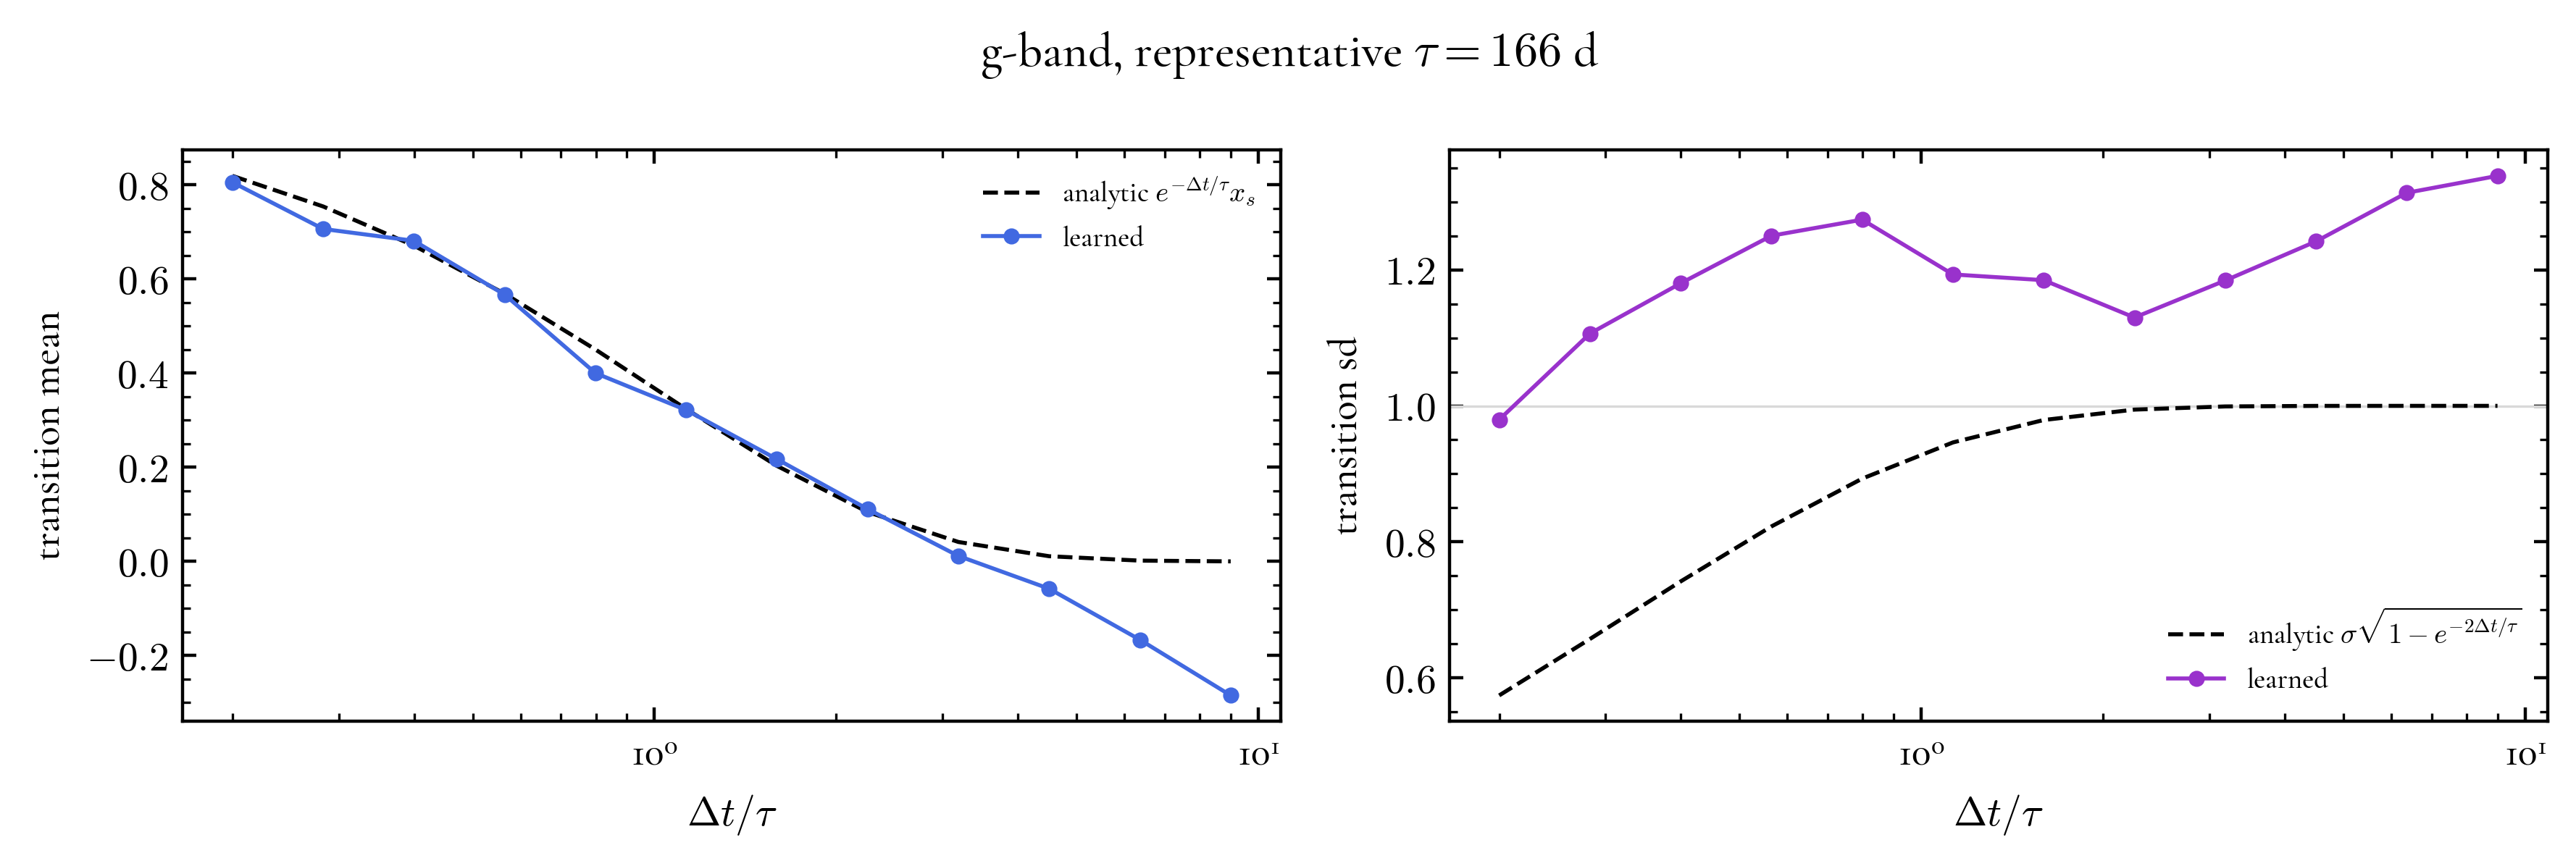

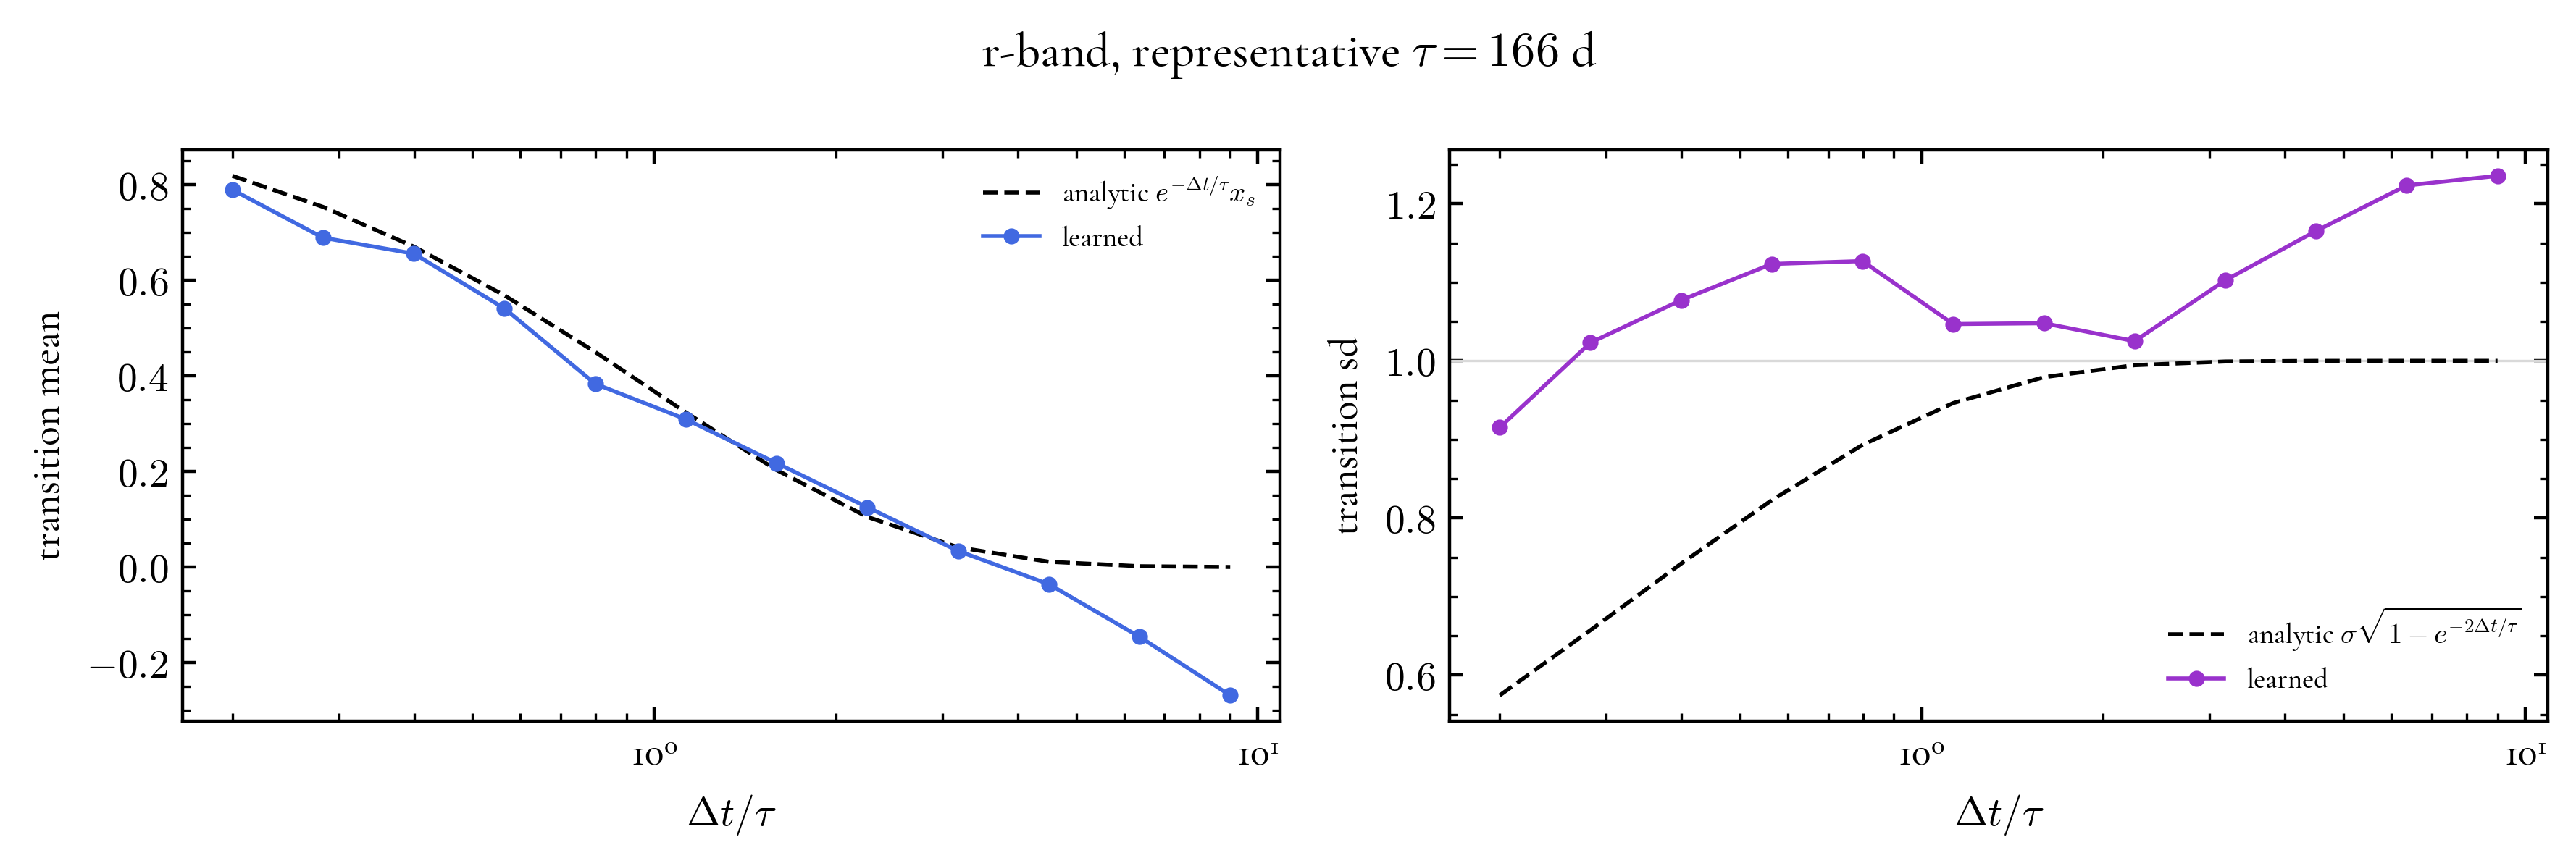

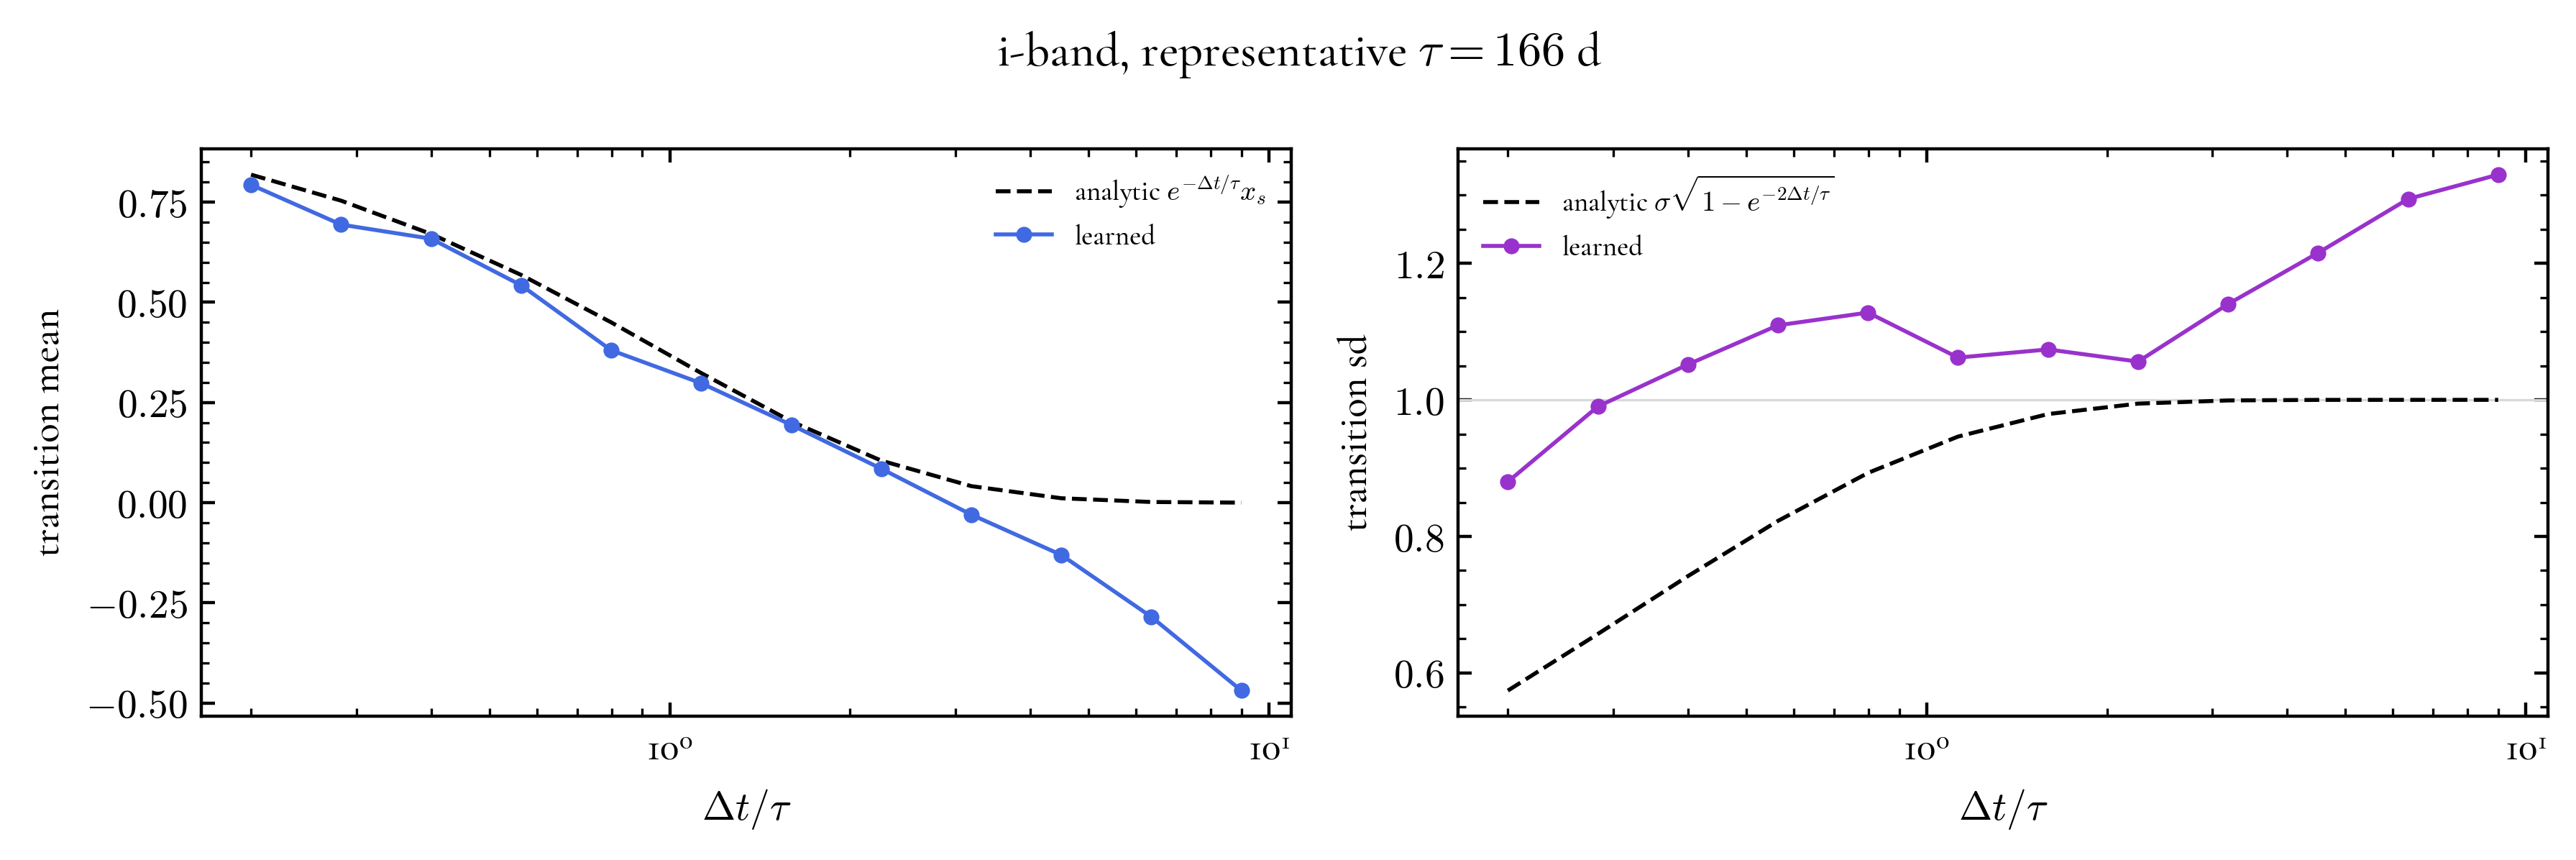

  sd   @ 9 tau : 1.33  (analytic 1.00)   -> must saturate at 1


In [8]:
for band in ["g", "r", "i"]:
    r = results[band]
    D, flow = r["D"], r["flow"]
    i_ref = int(np.argmin(np.abs(np.asarray(D["tau"]) - np.median(D["tau"]))))
    tau_ref, sig_ref = float(D["tau"][i_ref]), float(D["sigma"][i_ref])
    dts = np.logspace(np.log10(0.2*tau_ref), np.log10(9*tau_ref), 12)
    lm, lv, tm, tv = checkTransition(flow, tau_ref, sig_ref, 1.0, dts, random.PRNGKey(2), n=4000)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3))
    ax[0].plot(dts/tau_ref, tm, "k--", label=r"analytic $e^{-\Delta t/\tau}x_s$")
    ax[0].plot(dts/tau_ref, lm, "o-", ms=3, color="royalblue", label="learned")
    ax[0].set_ylabel("transition mean")
    ax[1].axhline(sig_ref, color="0.85", lw=.6)
    ax[1].plot(dts/tau_ref, np.sqrt(tv), "k--", label=r"analytic $\sigma\sqrt{1-e^{-2\Delta t/\tau}}$")
    ax[1].plot(dts/tau_ref, np.sqrt(lv), "o-", ms=3, color="darkorchid", label="learned")
    ax[1].set_ylabel("transition sd")
    for a in ax: a.set_xscale("log"); a.set_xlabel(r"$\Delta t/\tau$"); a.legend(fontsize=7)
    fig.suptitle(f"{band}-band, representative $\\tau={tau_ref*D['t_scale']:.0f}$ d")
    plt.tight_layout() 

    plt.savefig(f"/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/figures/LearnedTrans{band}.pdf")
    plt.show()

print(f"  sd   @ 9 tau : {np.sqrt(lv[-1]):.2f}  (analytic {np.sqrt(tv[-1]):.2f})   -> must saturate at 1")


## 4. Gap filling, against the Bayes-optimal baseline

The DRW-GP is handed the **true** $\tau$ and $\sigma$, and the data were generated from exactly that
process, making it the optimal filler by construction. 

Filling a gap means conditioning on **both** endpoints, that is what a bridge is. The transition
alone conditions on the left endpoint only, which is forecasting: it drifts and its band widens
monotonically.

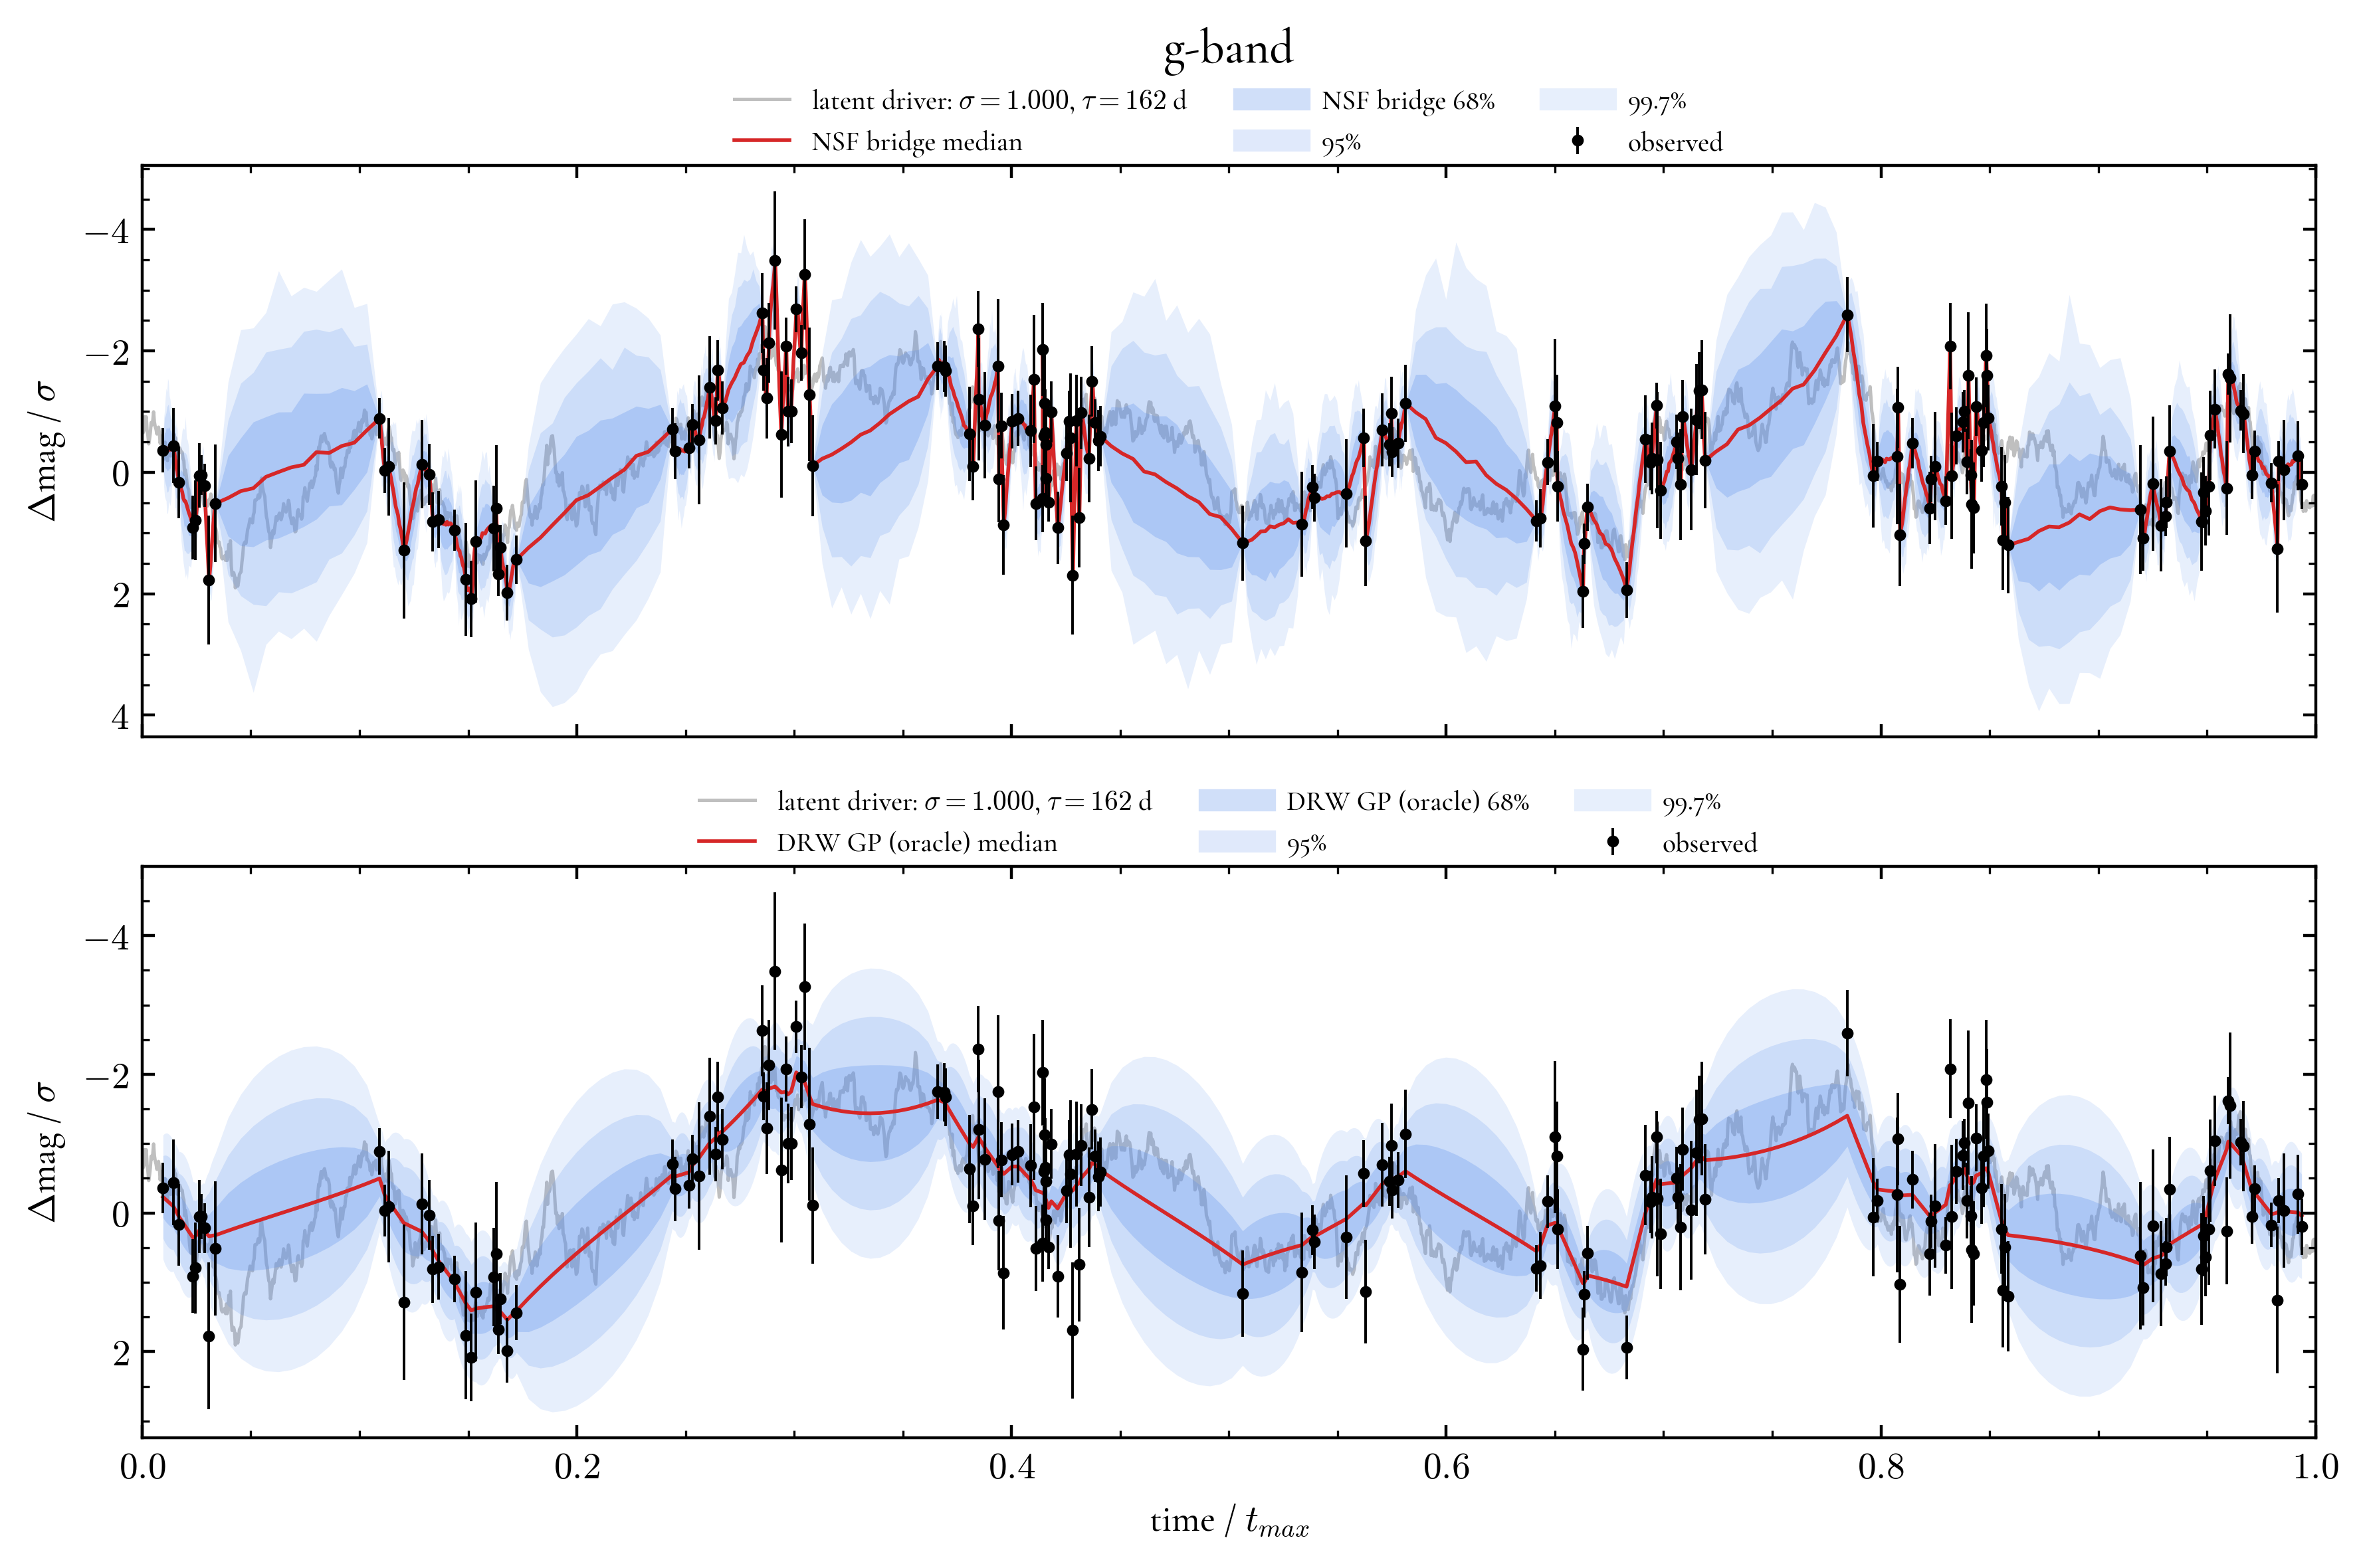

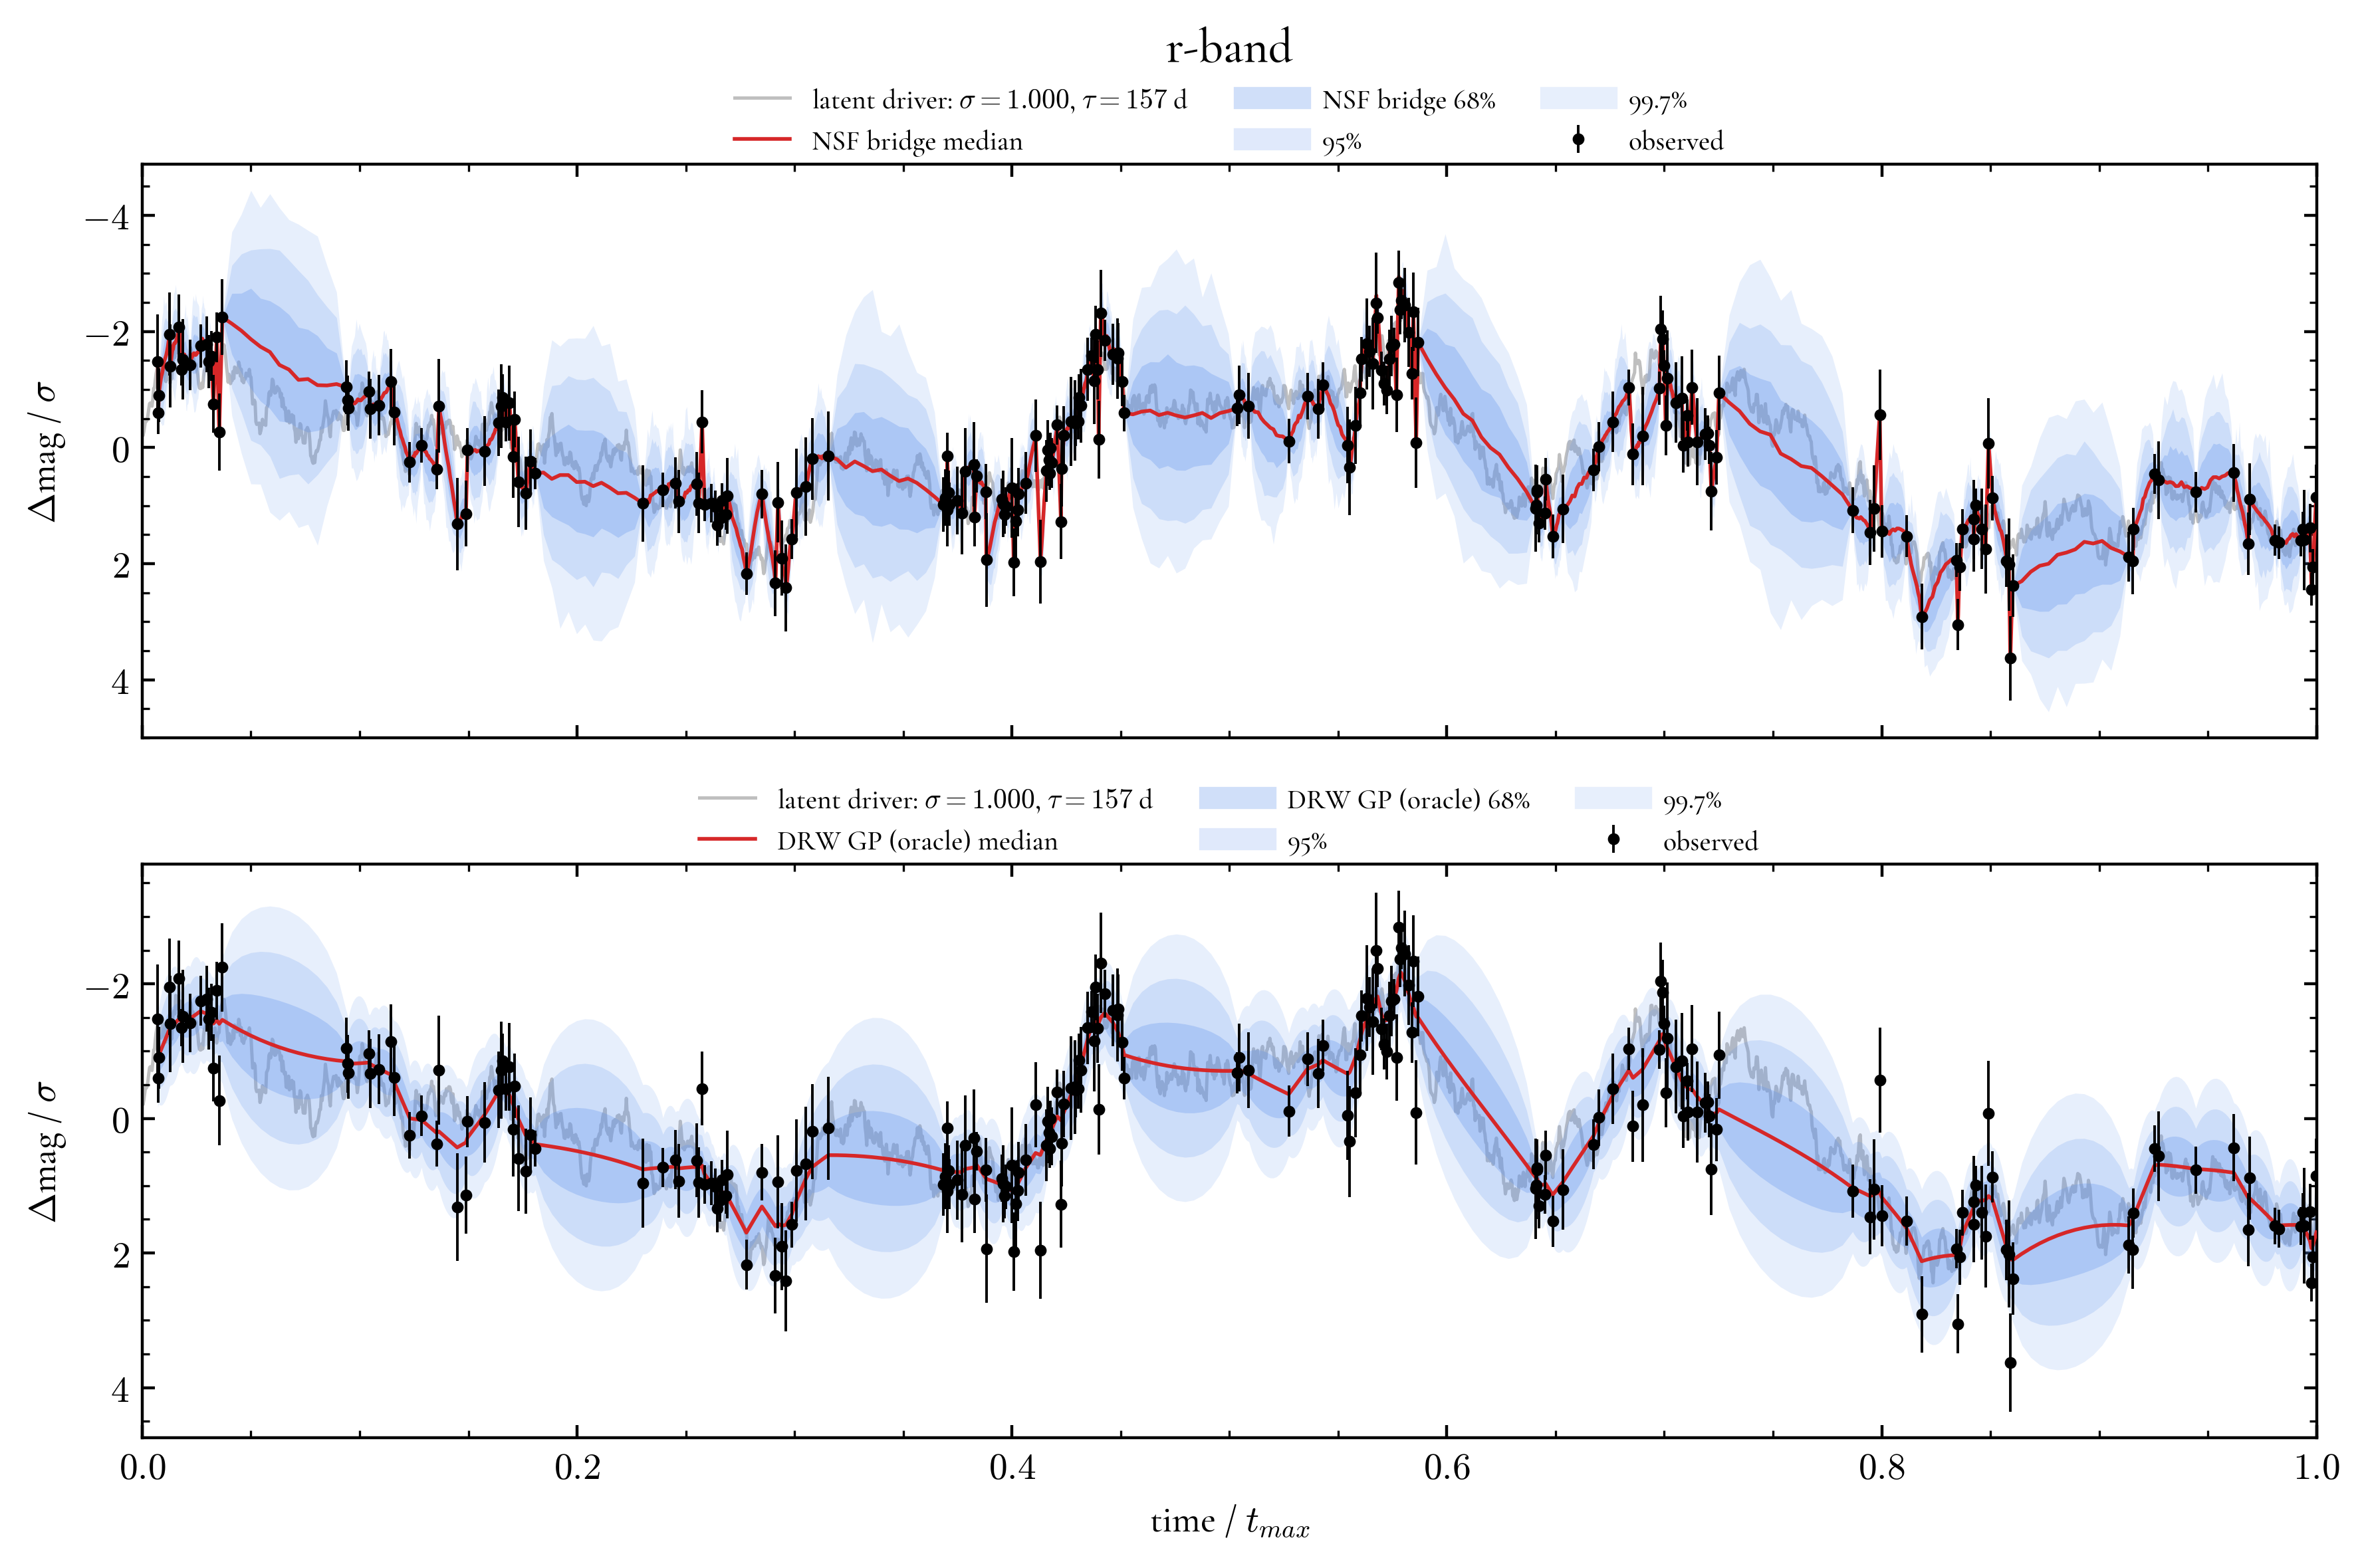

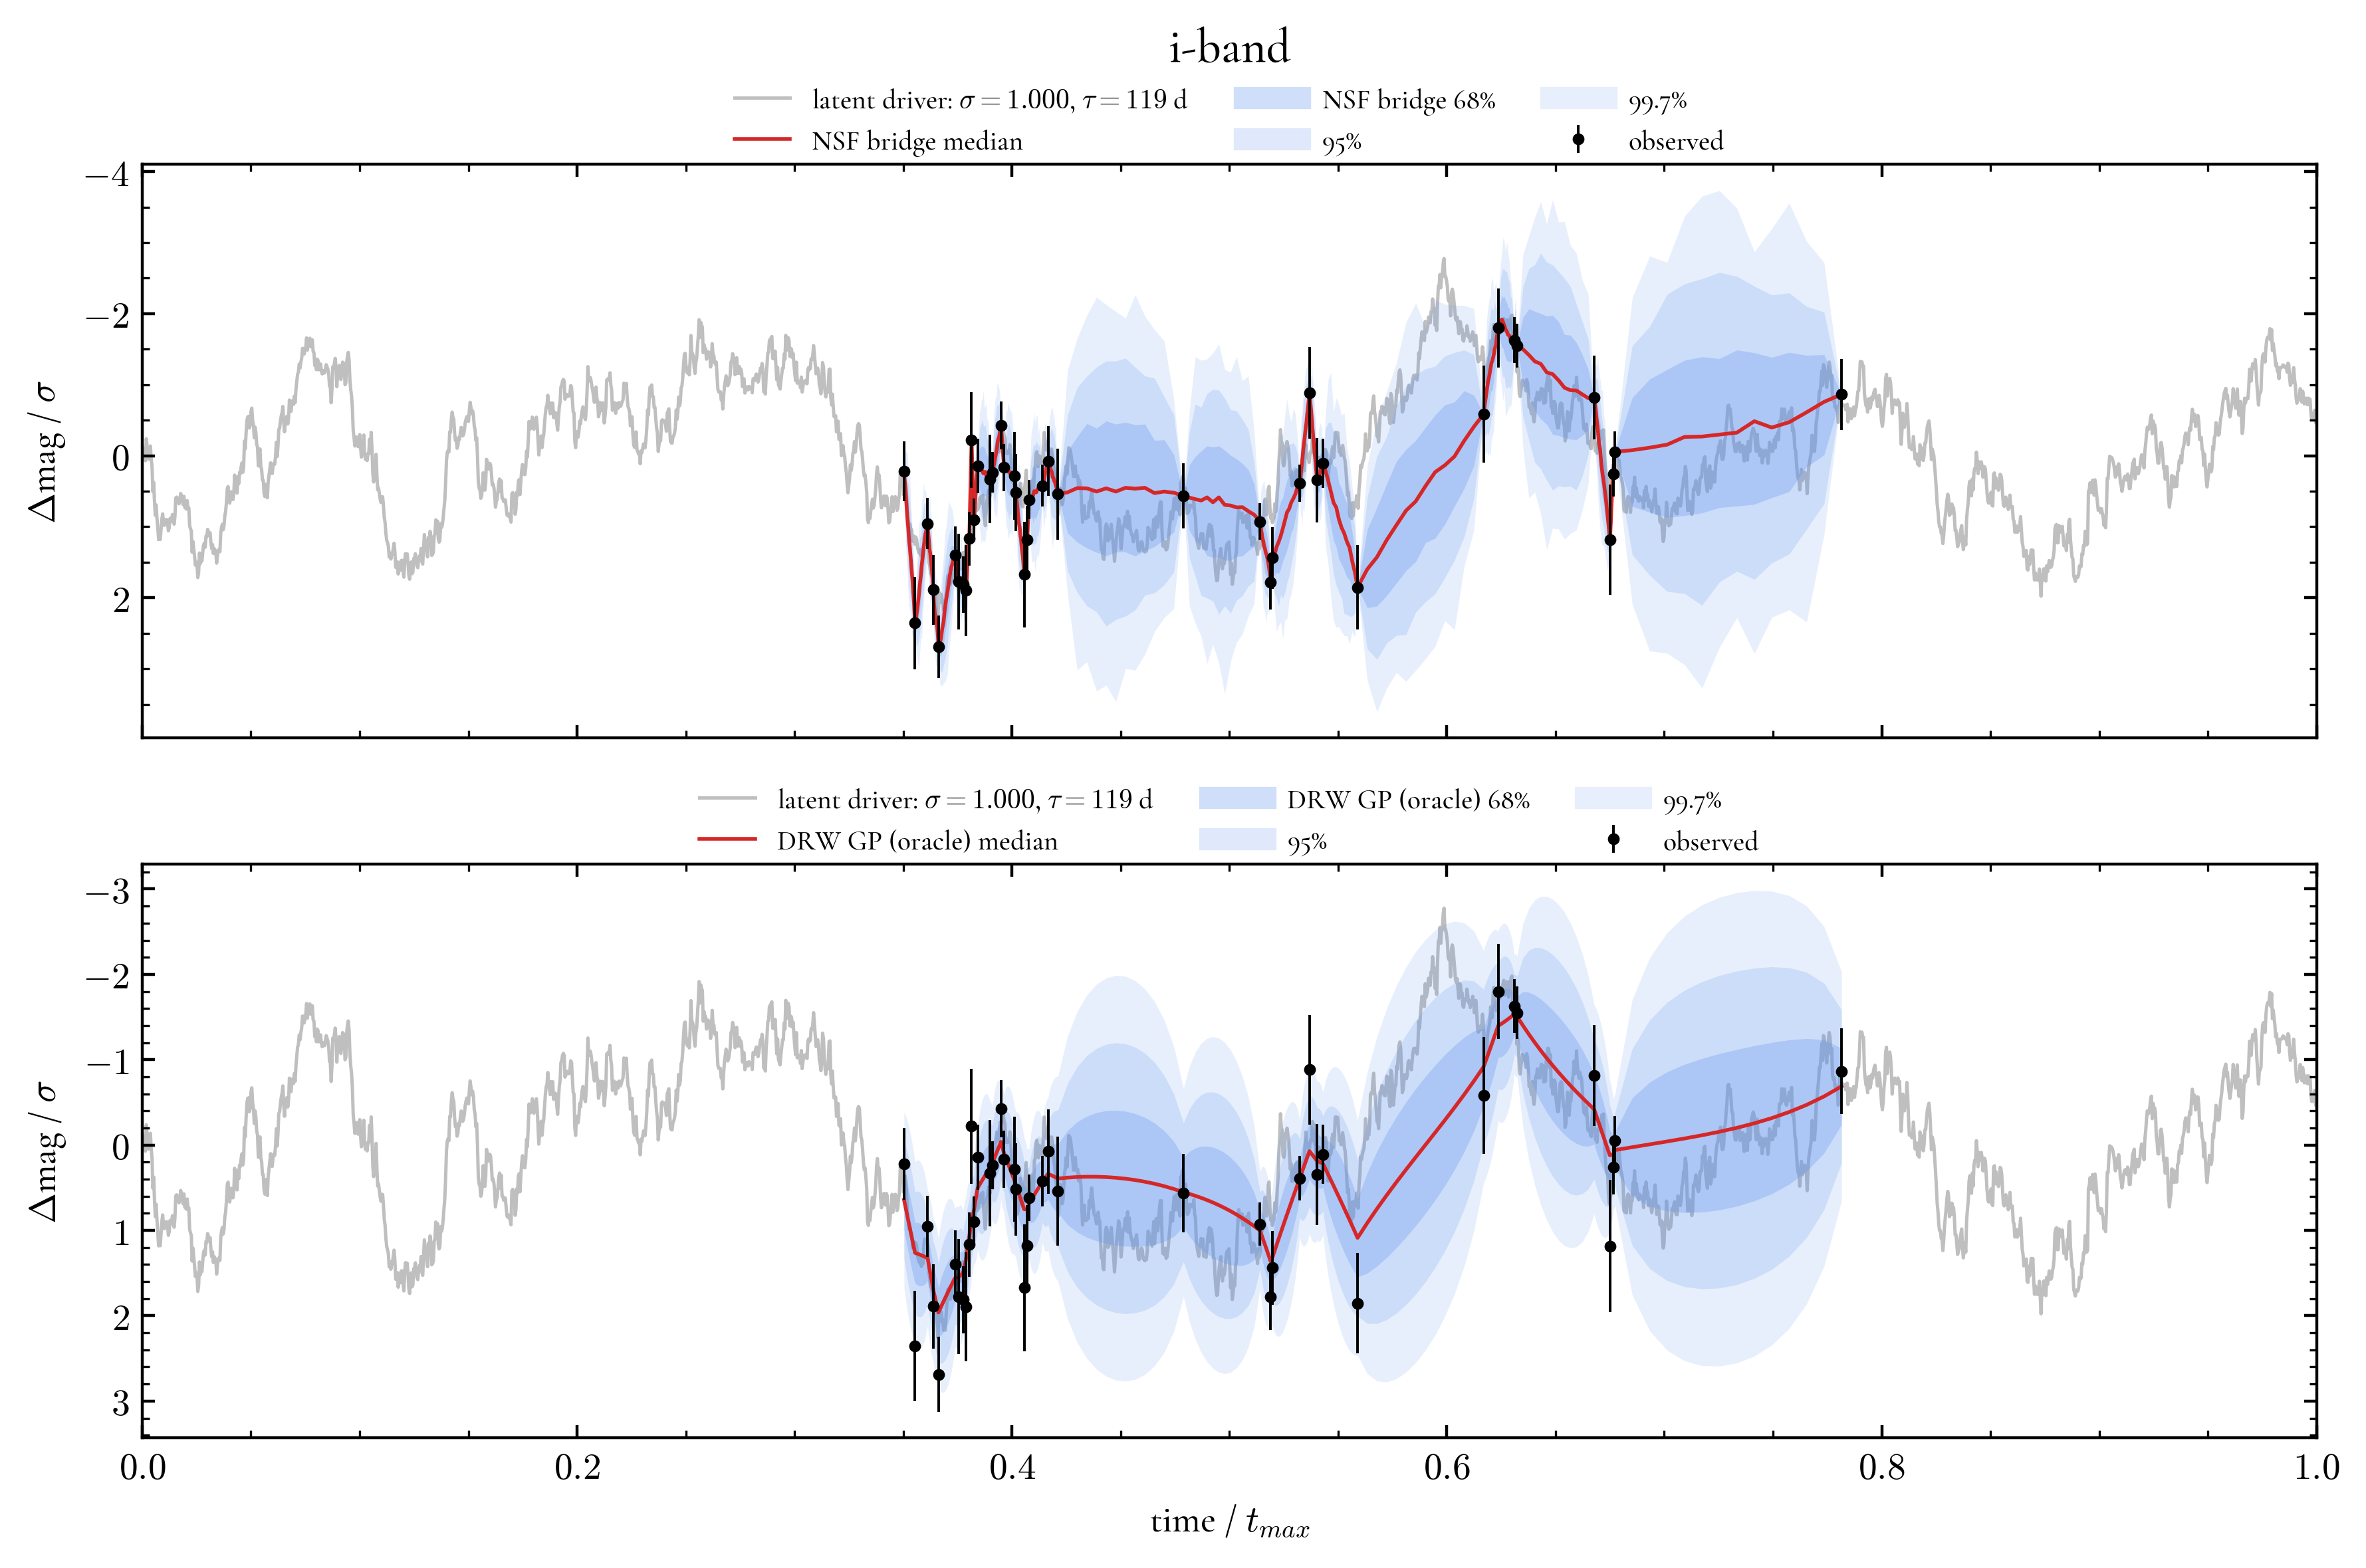

In [9]:
for band in ["g", "r", "i"]:
    r = results[band]; V, bridge, D = r["V"], r["bridge"], r["D"]
    # pick a curve with a wide gap
    gapsize = [np.max(np.diff(np.asarray(V["t"][i])[V["mask"][i]])) / float(V["tau"][i])
               for i in range(len(V["t"]))]
    i = int(np.argsort(gapsize)[len(gapsize)//2])   # mediand curve

    m = np.asarray(V["mask"][i])
    t_o, y_o, e_o = np.asarray(V["t"][i])[m], np.asarray(V["y"][i])[m], np.asarray(V["yerr"][i])[m]
    t_tr, y_tr = np.asarray(V["t_true"]), np.asarray(V["y_true"][i])
    tau_i, sig_i = float(V["tau"][i]), float(V["sigma"][i])

    t_rec, s_rec = fillGaps(bridge, t_o, y_o, n_samples=800, grid_per_gap=12, seed=0)
    mu, sd = drwGPBaseline(t_o, y_o, e_o, t_rec, tau_i, sig_i)


    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    plotGapFill(t_tr, y_tr, t_o, y_o, e_o, t_rec, s_rec, ax=axes[0], label="NSF bridge",
                tau=tau_i, sigma=sig_i, t_scale=D["t_scale"])
    plotGapFill(t_tr, y_tr, t_o, y_o, e_o, t_rec, (mu, sd), ax=axes[1],
                label=r"DRW GP (oracle)", tau=tau_i, sigma=sig_i, t_scale=D["t_scale"])
    axes[0].set_title(f"{band}-band", fontsize=13, pad = 28)
    axes[0].set_xlabel("")
    plt.tight_layout()
    
    plt.savefig(f"/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/figures/FilledGap{band}.pdf")
    plt.show()

## 5. Pooled error: GP vs Flow

In [10]:
## PREVIOUS VERSION 
#print(f"{'band':6s}{'':10s}{'coverage@68% (med,16-84)':>28s}{'RMSE (med,16-84)':>24s}")
#for band in ["g", "r", "i"]:
 #   res = results[band]["res"]
 #   for lab, ck, rk in [("NSF", "nsf_cov", "nsf_rmse"), ("GP", "gp_cov", "gp_rmse")]:
 #       cov = np.array([x[ck] for x in res]); rms = np.array([x[rk] for x in res])
 #       print(f"{band if lab=='NSF' else '':6s}{lab:10s}"
#              f"{np.median(cov):.2f} [{np.percentile(cov,16):.2f}, {np.percentile(cov,84):.2f}]"
 #             f"      {np.median(rms):.3f} [{np.percentile(rms,16):.3f}, {np.percentile(rms,84):.3f}]")
  #  dr = np.array([x["nsf_rmse"] - x["gp_rmse"] for x in res])
  #  print(f"       -> NSF {100*np.median(dr)/np.median([x['gp_rmse'] for x in res]):+.0f}% vs Bayes-optimal\n")

# band                coverage@68% (med,16-84)        RMSE (med,16-84)
#g     NSF       0.31 [0.28, 0.35]      0.567 [0.533, 0.598]
 #     GP        0.68 [0.64, 0.72]      0.296 [0.265, 0.360]
#       -> NSF +89% vs Bayes-optimal

#r     NSF       0.33 [0.31, 0.37]      0.454 [0.427, 0.478]
#      GP        0.69 [0.65, 0.72]      0.264 [0.226, 0.288]
#       -> NSF +72% vs Bayes-optimal

#i     NSF       0.42 [0.37, 0.47]      0.469 [0.428, 0.529]
#      GP        0.67 [0.62, 0.72]      0.318 [0.275, 0.380]
 #      -> NSF +46% vs Bayes-optimal

for band in ["g", "r", "i"]:
    res = results[band]["res"]
    print(f"\n=== {band}-band ===")
    print(f"{'':6s}" + "".join(f"cov{int(100*l):>6}" for l in (0.50,0.68,0.90,0.95))
          + f"{'RMSE':>9}{'predLL':>9}")
    for lab, ck, rk, lk in [("NSF", "nsf_cov", "nsf_rmse", "nsf_ll"),
                            ("GP ", "gp_cov",  "gp_rmse",  "gp_ll")]:
        covs = [np.median([x[ck][l] for x in res]) for l in (0.50,0.68,0.90,0.95)]
        rms  = np.median([x[rk] for x in res]); ll = np.median([x[lk] for x in res])
        print(f"{lab:6s}" + "".join(f"{c:>6.2f}" for c in covs) + f"{rms:>9.3f}{ll:>9.2f}")


=== g-band ===
      cov    50cov    68cov    90cov    95     RMSE   predLL
NSF     0.21  0.31  0.46  0.51    0.572   -10.15
GP      0.51  0.68  0.89  0.94    0.296    -0.12

=== r-band ===
      cov    50cov    68cov    90cov    95     RMSE   predLL
NSF     0.23  0.33  0.50  0.56    0.458    -8.64
GP      0.51  0.69  0.90  0.94    0.264     0.00

=== i-band ===
      cov    50cov    68cov    90cov    95     RMSE   predLL
NSF     0.31  0.43  0.61  0.67    0.470    -3.11
GP      0.50  0.67  0.89  0.94    0.318    -0.17


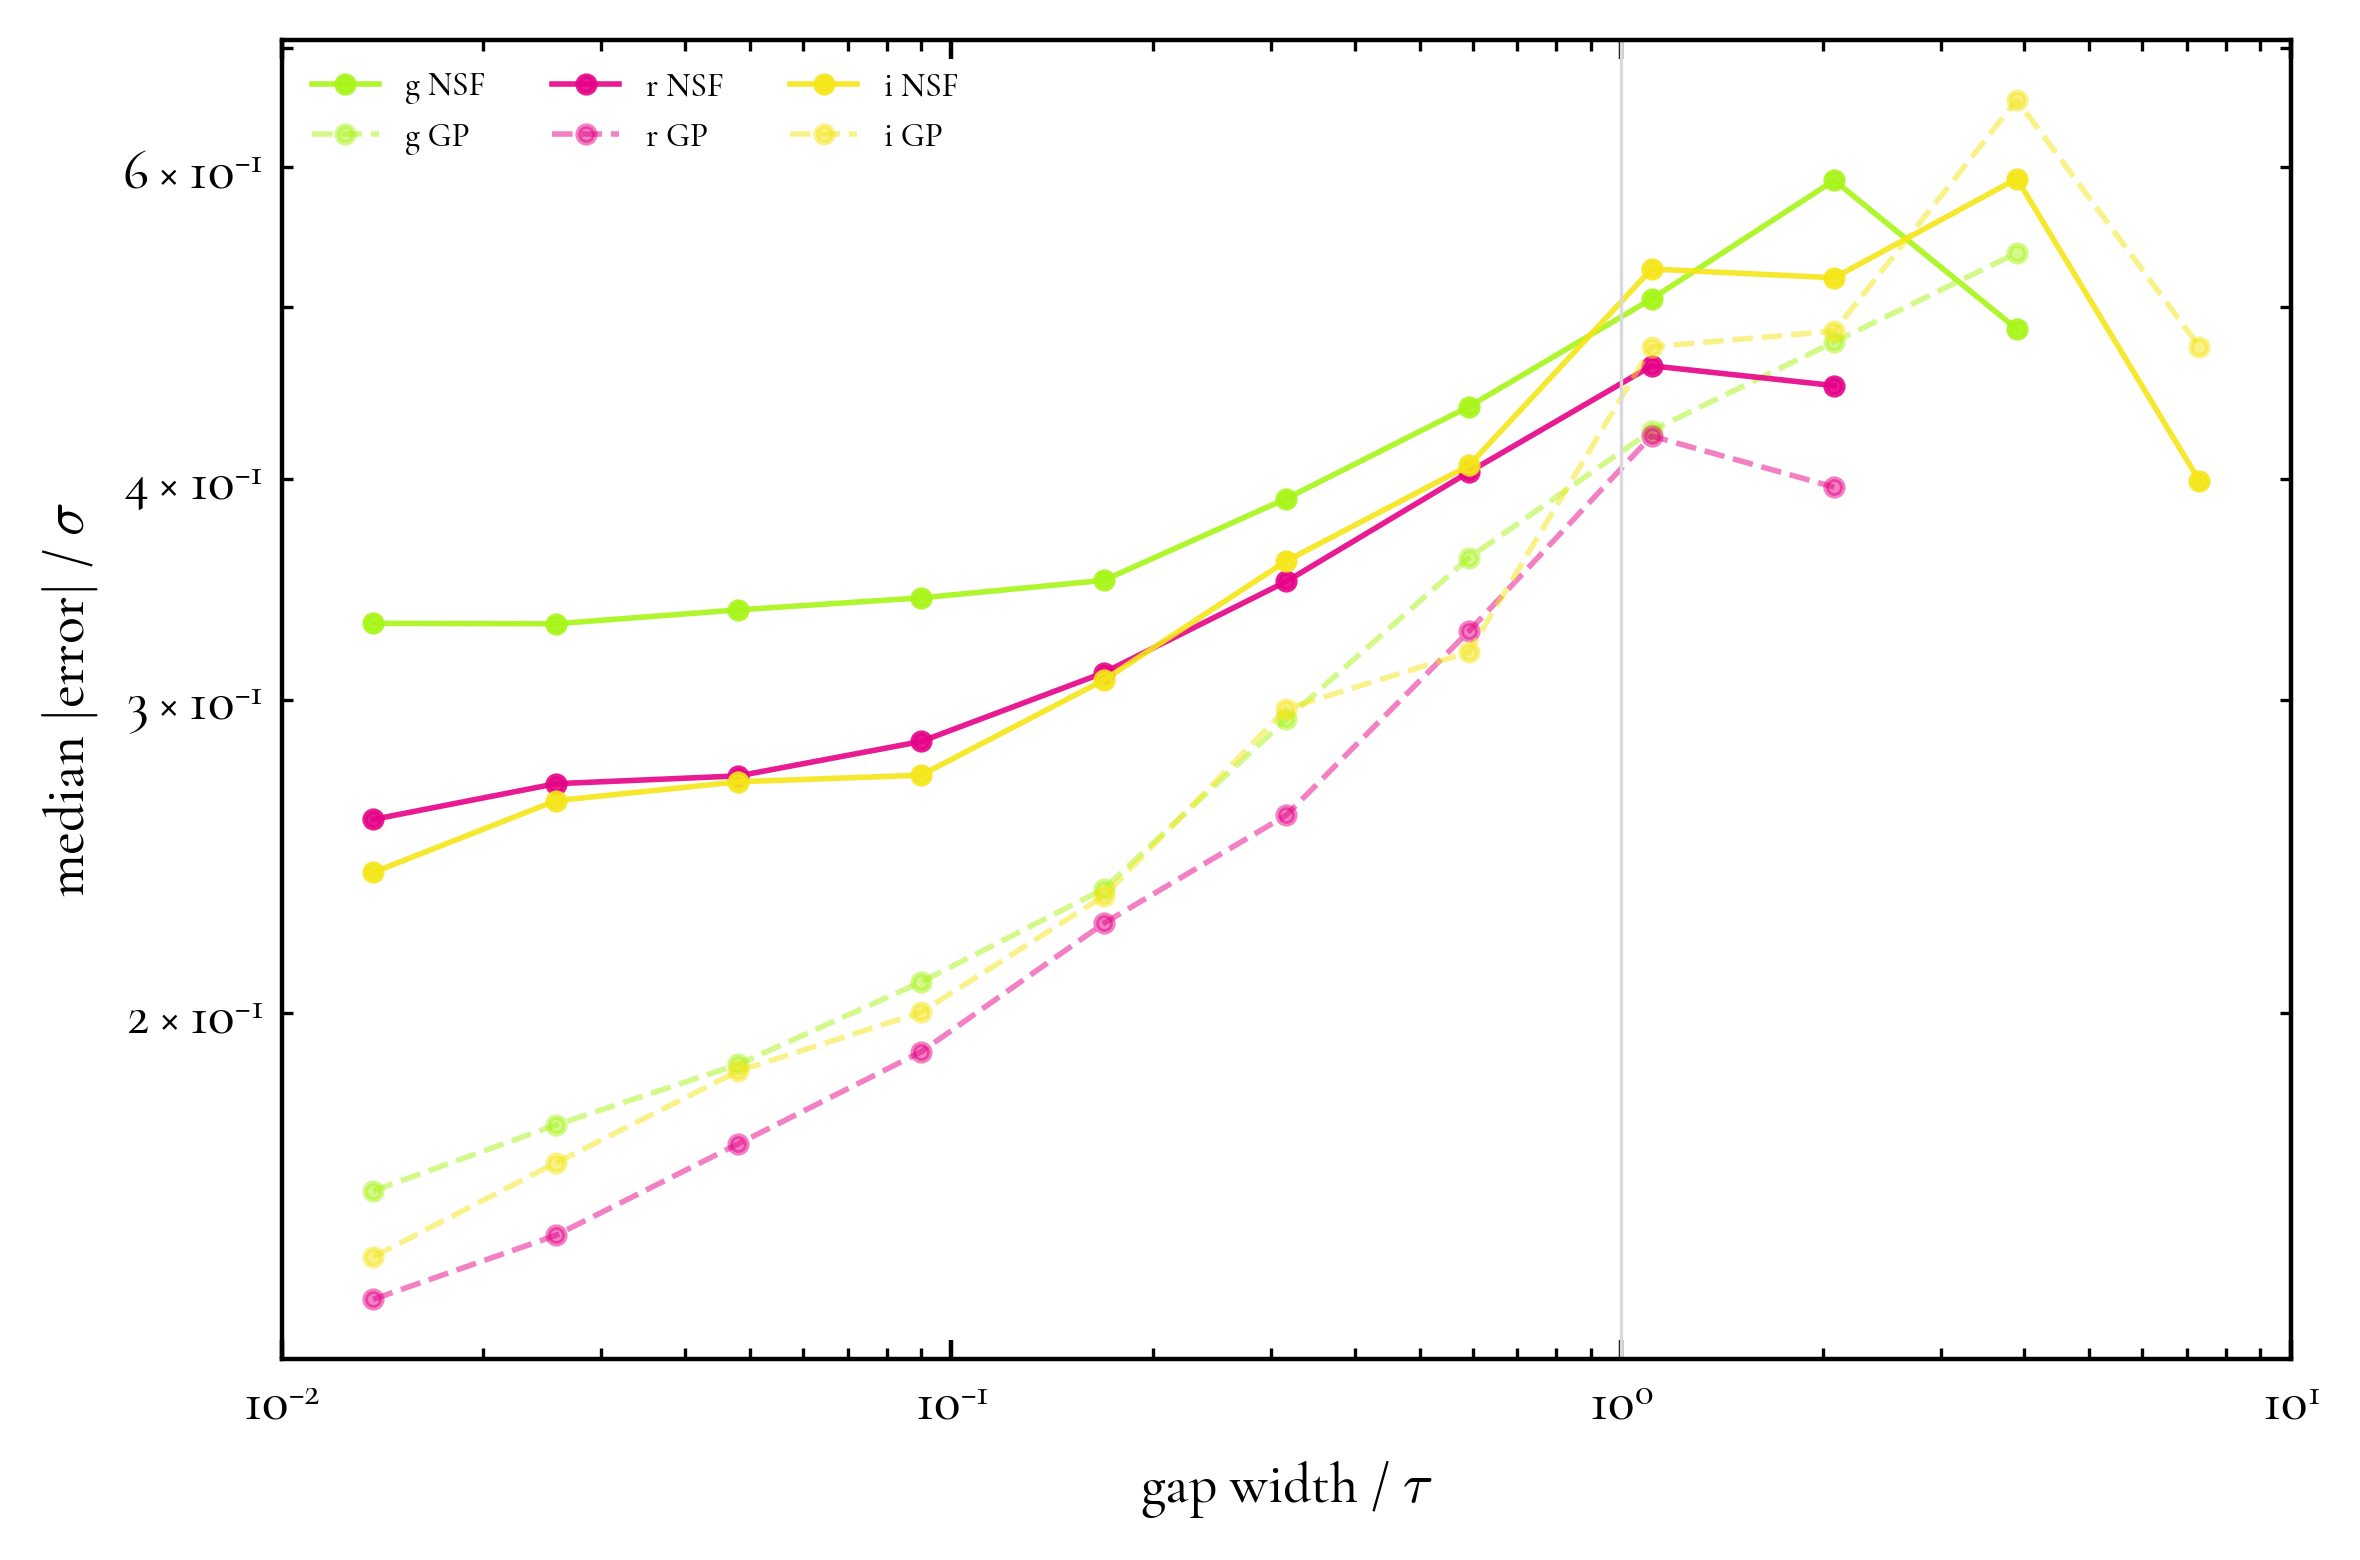

In [11]:

plt.figure(figsize=(6, 4))
band_col = {"g": "#a8f518", "r": "#e60287", "i": "#f5e618"}

for band in ["g", "r", "i"]:
    res = results[band]["res"]
    w   = np.concatenate([x["gap_tau"][x["interior"]] for x in res])
    enf = np.concatenate([np.abs(np.median(x["s_rec"],0) - x["y_ref"])[x["interior"]] for x in res])
    egp = np.concatenate([np.abs(x["mu"] - x["y_ref"])[x["interior"]] for x in res])

    bins = np.logspace(-2, 1, 12); cen = np.sqrt(bins[:-1]*bins[1:])   # extended to 10 tau 
    idx = np.digitize(w, bins) - 1
    for e, style, lab in [(enf, "-", f"{band} NSF"), (egp, "--", f"{band} GP")]:
        med = [np.median(e[idx==b]) if (idx==b).sum() > 20 else np.nan for b in range(len(cen))]
        plt.plot(cen, med, style, marker="o", ms=3, color=band_col[band],
                 label=lab, alpha=0.9 if style=="-" else 0.5)
plt.xscale("log"); plt.yscale("log"); plt.axvline(1.0, color="0.85", lw=.6)
plt.xlabel(r"gap width / $\tau$"); plt.ylabel(r"median $|$error$|$ / $\sigma$")
plt.legend(fontsize=6, ncol=3)
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/figures/Error.pdf")
plt.show()

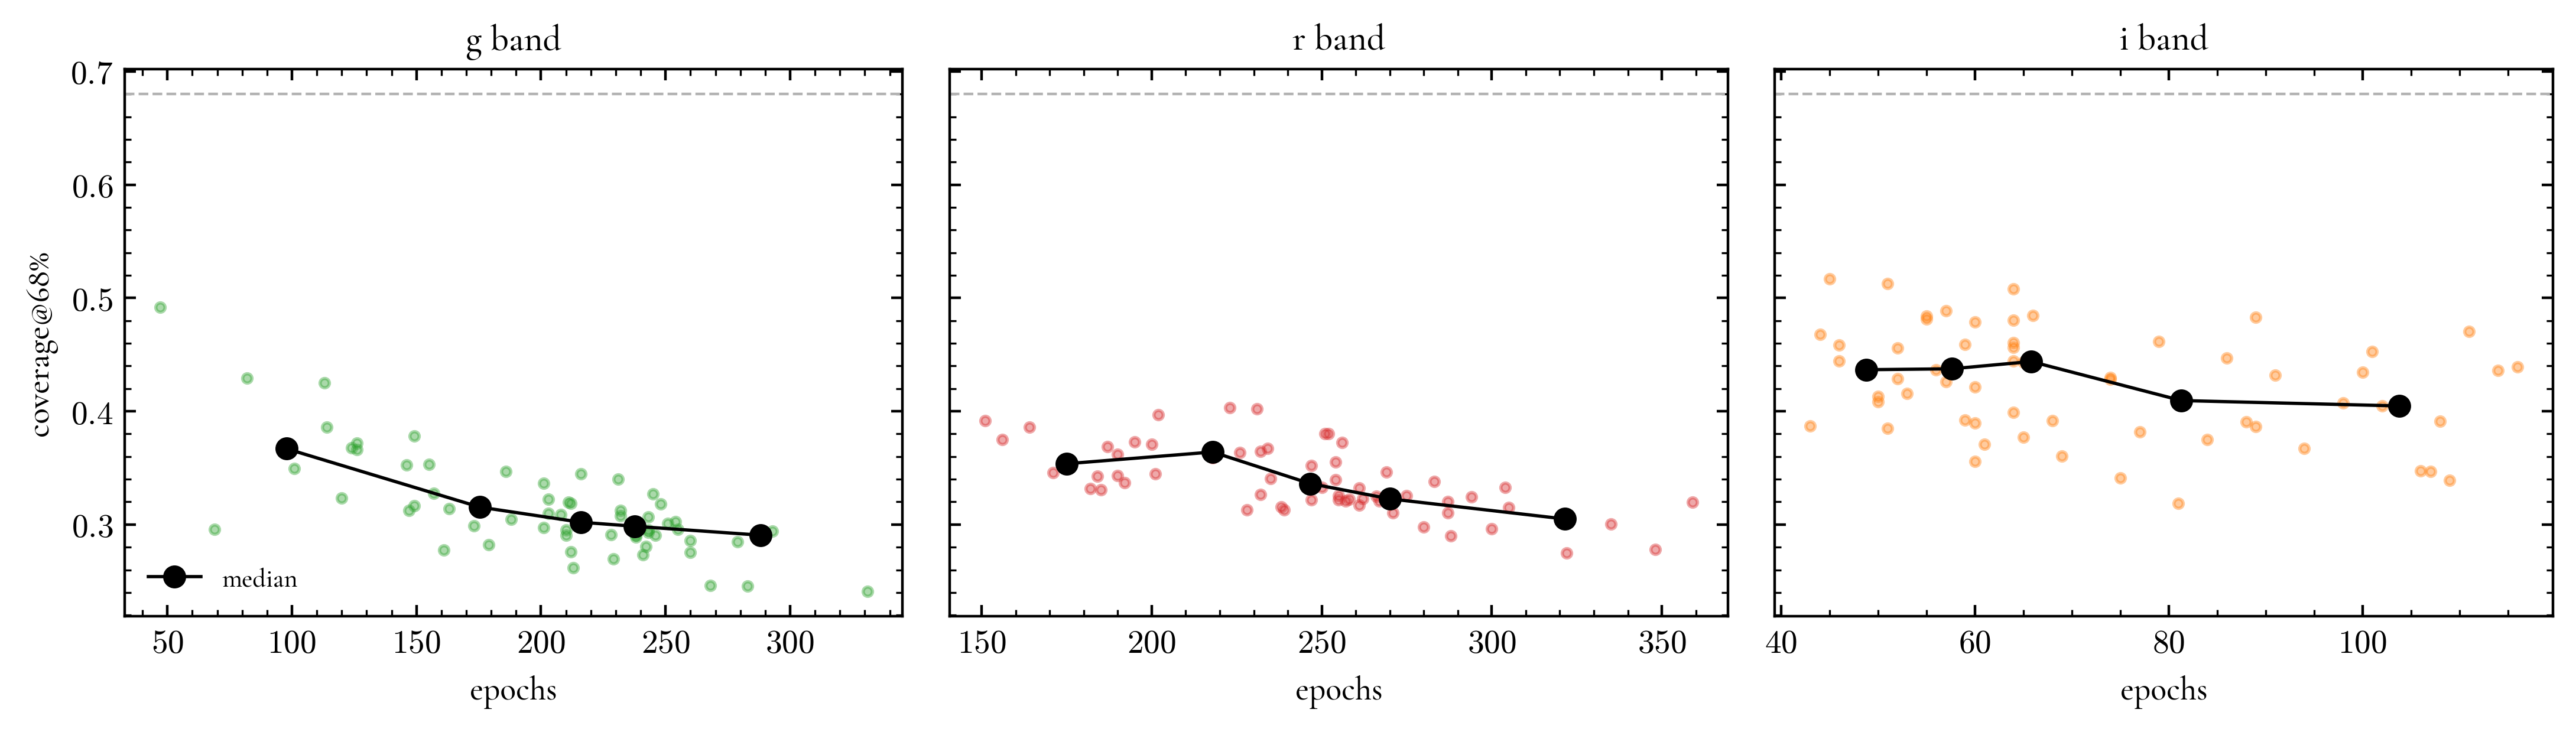

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)

colors = {"g": "tab:green", "r": "tab:red", "i": "tab:orange"}

for ax, band in zip(axes, ["g", "r", "i"]):
    res = results[band]["res"]
    nep = np.array([x["n_ep"] for x in res])
    cov = np.array([x["nsf_cov"][0.68] for x in res])

    ax.scatter(nep, cov, s=8, alpha=0.4, color=colors[band])

    bins = np.quantile(nep, np.linspace(0, 1, 6))
    cen  = 0.5 * (bins[:-1] + bins[1:])
    idx  = np.digitize(nep, bins) - 1
    med  = [np.median(cov[idx == b]) if (idx == b).sum() > 3 else np.nan
            for b in range(len(cen))]
    ax.plot(cen, med, "o-", color="k", label="median")

    ax.axhline(0.68, color="0.7", ls="--", lw=0.8)
    ax.set_xlabel("epochs")
    ax.set_title(f"{band} band", fontsize=11)

axes[0].set_ylabel("coverage@68%")
axes[0].legend(fontsize=8)

fig.tight_layout()
fig.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/figures/calibrationvsSN.pdf")
plt.show()


The S/N doesn't span a big range, all curves are low S/N so it is uniformly bad. The model gets worse with more epochs, possibly because it has more noisy data to anchor to, this is consistent with the i band having the better coverage, hinting that noise is the primary problem (also the fact that this trend is steepest in the g band. the noisiest).

note: Verify np.corrcoef(n_ep, tau)

## 6. Real ZTF Lightcurve

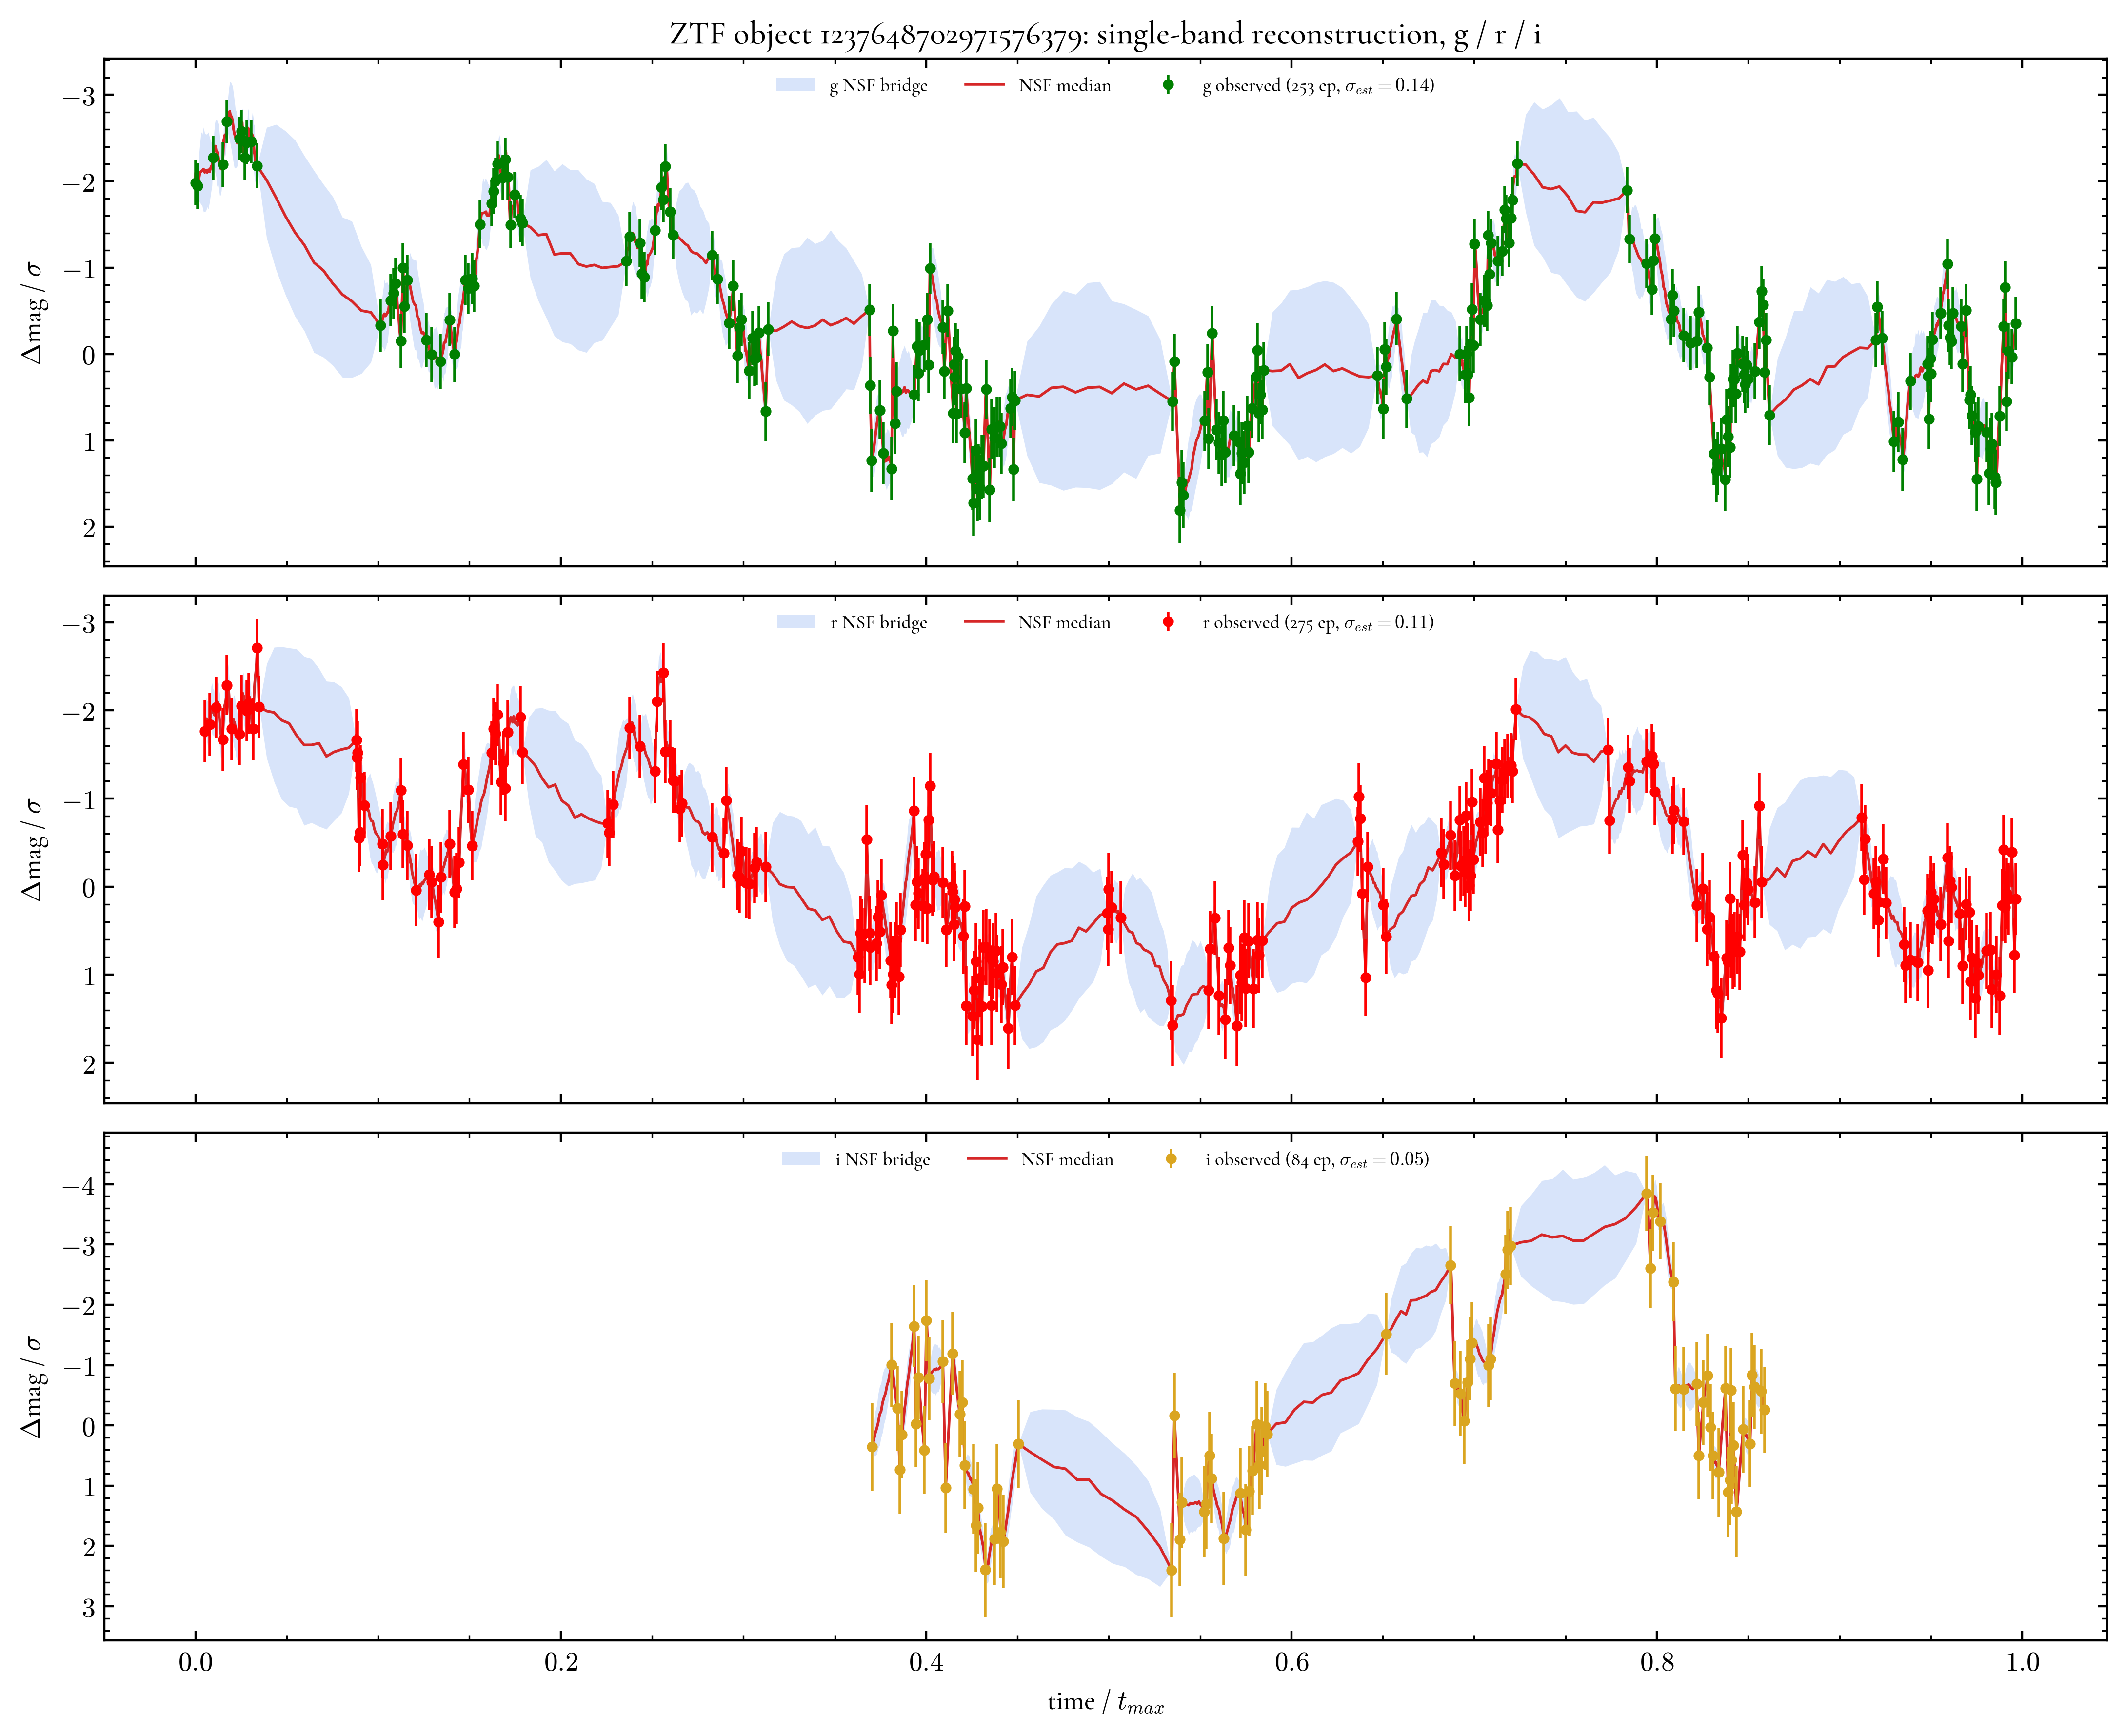

In [13]:
import pickle
from scipy.ndimage import median_filter
from scipy.optimize import minimize

sample = pickle.load(open(f"/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/lightcurves/ztf_sample.pkl", "rb"))   # your 150 curves

# one r-band object

oid = list(sample)[10]

# shared baseline 
mjd0 = min(sample[oid]["lc"][b]["mjd"].min() for b in ["g", "r", "i"])

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
band_col = {"g": "green", "r": "red", "i": "goldenrod"}

for ax, band in zip(axes, ["g", "r", "i"]):
    d = sample[oid]["lc"][band]
    t_real = d["mjd"].values - mjd0                       
    y_real = d["mag"].values
    e_real = d["magerr"].values

    # drop isolated bad epochs
    order = np.argsort(t_real); ys = y_real[order]
    resid = ys - median_filter(ys, size=5)
    sc = 1.48 * np.median(np.abs(resid - np.median(resid)))
    keep_s = np.abs(resid) < 5 * sc
    keep = np.zeros(len(t_real), bool); keep[order] = keep_s
    t_real, y_real, e_real = t_real[keep], y_real[keep], e_real[keep]

    # normalize each by the estimated params
    # Similarly, any normalization parameters used in a masking experiment should be estimated only 
    # from the retained observations, not from the complete light curve.

    robust = 1.48 * np.median(np.abs(y_real - np.median(y_real)))
    sigma_est = np.sqrt(max(robust**2 - np.median(e_real)**2, 0.01**2))
    t_scale = results[band]["D"]["t_scale"]
    t_n = t_real / t_scale
    y_n = (y_real - np.median(y_real)) / sigma_est
    e_n = e_real / sigma_est
 #   tau_n = float(np.median(results[band]["D"]["tau"]))

    # reconstruct 
    t_rec, s_rec = fillGaps(results[band]["bridge"], t_n, y_n,
                            n_samples=800, grid_per_gap=12, seed=0)
    lo, med, hi = np.percentile(s_rec, [16, 50, 84], axis=0)

    ax.fill_between(t_rec, lo, hi, color="cornflowerblue", alpha=0.25, lw=0, label=f"{band} NSF bridge")
    ax.plot(t_rec, med, color="tab:red", lw=1, label="NSF median")
    ax.errorbar(t_n, y_n, e_n, fmt="o", ms=3, color=band_col[band], capsize=0,
                label=f"{band} observed ({t_n.size} ep, $\\sigma_{{est}}={sigma_est:.2f}$)")
    ax.invert_yaxis(); ax.set_ylabel(r"$\Delta$mag / $\sigma$")
    ax.legend(fontsize=7, ncol=3, loc="upper center")

axes[2].set_xlabel(r"time / $t_{max}$")
axes[0].set_title(f"ZTF object {oid}: single-band reconstruction, g / r / i")
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/figures/ZTF_filled.pdf")
plt.show()

In [14]:
d = sample[oid]["lc"]["r"]
y = d["mag"].values
print(f"raw mag range: {y.min():.2f} to {y.max():.2f}, spread {y.max()-y.min():.2f}")
print(f"robust std (MAD): {1.48*np.median(np.abs(y-np.median(y))):.3f} mag")
print(f"points >0.4 mag from median: {np.sum(np.abs(y-np.median(y))>0.4)}")

raw mag range: 17.69 to 18.36, spread 0.67
robust std (MAD): 0.114 mag
points >0.4 mag from median: 1


## 6.1 Fit DRW params

In [15]:
def fitDRW(t, y, e):
    t = np.asarray(t,float); y = np.asarray(y,float) - np.median(y); e = np.asarray(e,float)
    def negll(p):
        tau, sig = np.exp(p)
        K = sig**2*np.exp(-np.abs(t[:,None]-t[None,:])/tau) + np.diag(e**2) + 1e-10*np.eye(len(t))
        try: L = np.linalg.cholesky(K)
        except np.linalg.LinAlgError: return 1e10
        a = np.linalg.solve(L.T, np.linalg.solve(L, y))
        return 0.5*y@a + np.sum(np.log(np.diag(L))) + 0.5*len(t)*np.log(2*np.pi)
    p0 = [np.log((t.max()-t.min())/5), np.log(np.std(y))]
    r = minimize(negll, p0, method="Nelder-Mead", options={"xatol":1e-3,"fatol":1e-3,"maxiter":500})
    return np.exp(r.x[0]), np.exp(r.x[1])


## 6.2 Masking random points

Masking both intervals and random single points

In [16]:
def maskCurve(t, rng, frac_random=0.10, n_intervals=2, interval_frac=0.08):
    """Returns (held, interval, scattered): held = all hidden points,
    interval = the contiguous-gap subset, scattered = the isolated singles."""
    n = len(t); interval = np.zeros(n, bool); span = t.max() - t.min()
    for _ in range(n_intervals):
        c = rng.uniform(t.min() + 0.1*span, t.max() - 0.1*span)
        interval |= np.abs(t - c) < 0.5*interval_frac*span
    held = interval.copy()
    avail = np.where(~held)[0]; n_rand = int(frac_random*n)
    if n_rand > 0 and len(avail) > n_rand:
        held[rng.choice(avail, n_rand, replace=False)] = True
    scattered = held & ~interval
    return held, interval, scattered

## 6.3 3-way comparison: NSF vs GP vs Linear Interp.

In [17]:
band = "g"
rng = np.random.default_rng(0)
rows = []

for oid, v in sample.items():
    if band not in v["lc"]:
        continue
    d = v["lc"][band]
    t = d["mjd"].values - d["mjd"].values.min()
    y = d["mag"].values
    e = d["magerr"].values

    # sort everything by time 
    o = np.argsort(t)
    t, y, e = t[o], y[o], e[o]

    # clip isolated outliers (local median filter, 5-sigma)
    resid = y - median_filter(y, size=5)
    sc = 1.48 * np.median(np.abs(resid - np.median(resid)))
    keep = np.abs(resid) < 5 * sc
    t, y, e = t[keep], y[keep], e[keep]
    if len(t) < 80:
        continue

    # mask: held = all hidden, interval = contiguous-gap subset, scattered = singles
    held, interval, scattered = maskCurve(t, rng)
    if held.sum() < 10:
        continue

    ret = ~held
    t_ret, y_ret, e_ret = t[ret], y[ret], e[ret]
    t_hid, y_hid, e_hid = t[held], y[held], e[held]

    # fit DRW on retained points only
    tau_fit, sig_fit = fitDRW(t_ret, y_ret, e_ret)
    baseline = t_ret.max() - t_ret.min()
    if not (1 < tau_fit < baseline) or not np.isfinite(sig_fit) or sig_fit <= 0:
        continue

    # normalize from retained points only (no leakage)
    ts = results[band]["D"]["t_scale"]
    y_med = np.median(y_ret)
    tn_ret = t_ret / ts
    yn_ret = (y_ret - y_med) / sig_fit
    en_ret = e_ret / sig_fit
    tn_hid = t_hid / ts
    yn_hid = (y_hid - y_med) / sig_fit
    en_hid = e_hid / sig_fit                      
    tau_n = tau_fit / ts

    # nsf
    t_rec, s_rec = fillGaps(results[band]["bridge"], tn_ret, yn_ret,
                            n_samples=200, grid_per_gap=12, seed=0)
    t_rec = np.asarray(t_rec)
    s_rec = np.asarray(s_rec)
    ro = np.argsort(t_rec)                          # np.interp needs sorted x
    t_rec, s_rec = t_rec[ro], s_rec[:, ro]

    nsf_med = np.interp(tn_hid, t_rec, np.median(s_rec, axis=0))
    nsf_lo = np.interp(tn_hid, t_rec, np.percentile(s_rec, 16, axis=0)) - en_hid
    nsf_hi = np.interp(tn_hid, t_rec, np.percentile(s_rec, 84, axis=0)) + en_hid

    # fitted params
    mu, sd = drwGPBaseline(tn_ret, yn_ret, en_ret, tn_hid, tau_n, 1.0)
    sd_obs = np.sqrt(sd**2 + en_hid**2)            # add hidden-point noise in quadrature
    gp_lo, gp_hi = mu - sd_obs, mu + sd_obs

    # linear interp
    lin = np.interp(tn_hid, tn_ret, yn_ret)
    hid_int = interval[held]
    hid_sca = scattered[held]

    def score(sub, kind):
        if sub.sum() < 5:
            return None
        yh = yn_hid[sub]
        return dict(kind=kind, oid=oid,
            nsf_cov=float(np.mean((yh >= nsf_lo[sub]) & (yh <= nsf_hi[sub]))),
            gp_cov =float(np.mean((yh >= gp_lo[sub]) & (yh <= gp_hi[sub]))),
            nsf_rmse=float(np.sqrt(np.mean((nsf_med[sub] - yh)**2))),
            gp_rmse =float(np.sqrt(np.mean((mu[sub] - yh)**2))),
            lin_rmse=float(np.sqrt(np.mean((lin[sub] - yh)**2))))

    for sub, kind in [(hid_sca, "scattered"), (hid_int, "interval")]:
        r = score(sub, kind)
        if r:
            rows.append(r)

print(f"real ZTF {band}-band, held-out prediction\n")
for kind in ["scattered", "interval"]:
    rk = [r for r in rows if r["kind"] == kind]
    if not rk:
        print(f"--- {kind}: no curves ---\n")
        continue
    print(f"--- {kind} points ({len(rk)} curves) ---")
    print(f"{'method':16}{'cov@68':>10}{'RMSE':>10}")
    print(f"{'NSF bridge':16}{np.median([r['nsf_cov'] for r in rk]):>10.2f}"
          f"{np.median([r['nsf_rmse'] for r in rk]):>10.3f}")
    print(f"{'fitted GP':16}{np.median([r['gp_cov'] for r in rk]):>10.2f}"
          f"{np.median([r['gp_rmse'] for r in rk]):>10.3f}")
    print(f"{'linear':16}{'--':>10}"
          f"{np.median([r['lin_rmse'] for r in rk]):>10.3f}\n")

real ZTF g-band, held-out prediction

--- scattered points (135 curves) ---
method              cov@68      RMSE
NSF bridge            0.74     0.907
fitted GP             0.73     0.784
linear                  --     0.897

--- interval points (134 curves) ---
method              cov@68      RMSE
NSF bridge            0.88     1.019
fitted GP             0.74     0.963
linear                  --     1.029



Interpolation has the worst RMSE and gives no uncertainty. RMSE in both the NSF and GP it is higher here than in the simulated case because instead of comparing to the latent truth we are comparing against the held out observations that carry noise themselves. 

The GP process is uncalibrated and overconfident as well now, mainly because the DRW parameters are fitted now. The NSF is more competitive with the GP in real data were the real DRW parameters are unknown, the coverage sits closer to it thatn on the simulated version. 

In [18]:
band = "r"
rng = np.random.default_rng(0)
rows = []

for oid, v in sample.items():
    if band not in v["lc"]:
        continue
    d = v["lc"][band]
    t = d["mjd"].values - d["mjd"].values.min()
    y = d["mag"].values
    e = d["magerr"].values

    # sort everything by time 
    o = np.argsort(t)
    t, y, e = t[o], y[o], e[o]

    # clip isolated outliers (local median filter, 5-sigma)
    resid = y - median_filter(y, size=5)
    sc = 1.48 * np.median(np.abs(resid - np.median(resid)))
    keep = np.abs(resid) < 5 * sc
    t, y, e = t[keep], y[keep], e[keep]
    if len(t) < 80:
        continue

    # mask: held = all hidden, interval = contiguous-gap subset, scattered = singles
    held, interval, scattered = maskCurve(t, rng)
    if held.sum() < 10:
        continue

    ret = ~held
    t_ret, y_ret, e_ret = t[ret], y[ret], e[ret]
    t_hid, y_hid, e_hid = t[held], y[held], e[held]

    # fit DRW on retained points only
    tau_fit, sig_fit = fitDRW(t_ret, y_ret, e_ret)
    baseline = t_ret.max() - t_ret.min()
    if not (1 < tau_fit < baseline) or not np.isfinite(sig_fit) or sig_fit <= 0:
        continue

    # normalize from retained points only (no leakage)
    ts = results[band]["D"]["t_scale"]
    y_med = np.median(y_ret)
    tn_ret = t_ret / ts
    yn_ret = (y_ret - y_med) / sig_fit
    en_ret = e_ret / sig_fit
    tn_hid = t_hid / ts
    yn_hid = (y_hid - y_med) / sig_fit
    en_hid = e_hid / sig_fit                      
    tau_n = tau_fit / ts

    # nsf
    t_rec, s_rec = fillGaps(results[band]["bridge"], tn_ret, yn_ret,
                            n_samples=200, grid_per_gap=12, seed=0)
    t_rec = np.asarray(t_rec)
    s_rec = np.asarray(s_rec)
    ro = np.argsort(t_rec)                          # np.interp needs sorted x
    t_rec, s_rec = t_rec[ro], s_rec[:, ro]

    nsf_med = np.interp(tn_hid, t_rec, np.median(s_rec, axis=0))
    nsf_lo = np.interp(tn_hid, t_rec, np.percentile(s_rec, 16, axis=0)) - en_hid
    nsf_hi = np.interp(tn_hid, t_rec, np.percentile(s_rec, 84, axis=0)) + en_hid

    # fitted params
    mu, sd = drwGPBaseline(tn_ret, yn_ret, en_ret, tn_hid, tau_n, 1.0)
    sd_obs = np.sqrt(sd**2 + en_hid**2)            # add hidden-point noise in quadrature
    gp_lo, gp_hi = mu - sd_obs, mu + sd_obs

    # linear interp
    lin = np.interp(tn_hid, tn_ret, yn_ret)
    hid_int = interval[held]
    hid_sca = scattered[held]

    def score(sub, kind):
        if sub.sum() < 5:
            return None
        yh = yn_hid[sub]
        return dict(kind=kind, oid=oid,
            nsf_cov=float(np.mean((yh >= nsf_lo[sub]) & (yh <= nsf_hi[sub]))),
            gp_cov =float(np.mean((yh >= gp_lo[sub]) & (yh <= gp_hi[sub]))),
            nsf_rmse=float(np.sqrt(np.mean((nsf_med[sub] - yh)**2))),
            gp_rmse =float(np.sqrt(np.mean((mu[sub] - yh)**2))),
            lin_rmse=float(np.sqrt(np.mean((lin[sub] - yh)**2))))

    for sub, kind in [(hid_sca, "scattered"), (hid_int, "interval")]:
        r = score(sub, kind)
        if r:
            rows.append(r)

print(f"real ZTF {band}-band, held-out prediction\n")
for kind in ["scattered", "interval"]:
    rk = [r for r in rows if r["kind"] == kind]
    if not rk:
        print(f"--- {kind}: no curves ---\n")
        continue
    print(f"--- {kind} points ({len(rk)} curves) ---")
    print(f"{'method':16}{'cov@68':>10}{'RMSE':>10}")
    print(f"{'NSF bridge':16}{np.median([r['nsf_cov'] for r in rk]):>10.2f}"
          f"{np.median([r['nsf_rmse'] for r in rk]):>10.3f}")
    print(f"{'fitted GP':16}{np.median([r['gp_cov'] for r in rk]):>10.2f}"
          f"{np.median([r['gp_rmse'] for r in rk]):>10.3f}")
    print(f"{'linear':16}{'--':>10}"
          f"{np.median([r['lin_rmse'] for r in rk]):>10.3f}\n")

real ZTF r-band, held-out prediction

--- scattered points (139 curves) ---
method              cov@68      RMSE
NSF bridge            0.68     0.995
fitted GP             0.71     0.887
linear                  --     0.994

--- interval points (139 curves) ---
method              cov@68      RMSE
NSF bridge            0.85     1.080
fitted GP             0.75     1.012
linear                  --     1.110



In [19]:
band = "i"
rng = np.random.default_rng(0)
rows = []

for oid, v in sample.items():
    if band not in v["lc"]:
        continue
    d = v["lc"][band]
    t = d["mjd"].values - d["mjd"].values.min()
    y = d["mag"].values
    e = d["magerr"].values

    # sort everything by time 
    o = np.argsort(t)
    t, y, e = t[o], y[o], e[o]

    # clip isolated outliers (local median filter, 5-sigma)
    resid = y - median_filter(y, size=5)
    sc = 1.48 * np.median(np.abs(resid - np.median(resid)))
    keep = np.abs(resid) < 5 * sc
    t, y, e = t[keep], y[keep], e[keep]
    if len(t) < 80:
        continue

    # mask: held = all hidden, interval = contiguous-gap subset, scattered = singles
    held, interval, scattered = maskCurve(t, rng)
    if held.sum() < 10:
        continue

    ret = ~held
    t_ret, y_ret, e_ret = t[ret], y[ret], e[ret]
    t_hid, y_hid, e_hid = t[held], y[held], e[held]

    # fit DRW on retained points only
    tau_fit, sig_fit = fitDRW(t_ret, y_ret, e_ret)
    baseline = t_ret.max() - t_ret.min()
    if not (1 < tau_fit < baseline) or not np.isfinite(sig_fit) or sig_fit <= 0:
        continue

    # normalize from retained points only (no leakage)
    ts = results[band]["D"]["t_scale"]
    y_med = np.median(y_ret)
    tn_ret = t_ret / ts
    yn_ret = (y_ret - y_med) / sig_fit
    en_ret = e_ret / sig_fit
    tn_hid = t_hid / ts
    yn_hid = (y_hid - y_med) / sig_fit
    en_hid = e_hid / sig_fit                      
    tau_n = tau_fit / ts

    # nsf
    t_rec, s_rec = fillGaps(results[band]["bridge"], tn_ret, yn_ret,
                            n_samples=200, grid_per_gap=12, seed=0)
    t_rec = np.asarray(t_rec)
    s_rec = np.asarray(s_rec)
    ro = np.argsort(t_rec)                          # np.interp needs sorted x
    t_rec, s_rec = t_rec[ro], s_rec[:, ro]

    nsf_med = np.interp(tn_hid, t_rec, np.median(s_rec, axis=0))
    nsf_lo = np.interp(tn_hid, t_rec, np.percentile(s_rec, 16, axis=0)) - en_hid
    nsf_hi = np.interp(tn_hid, t_rec, np.percentile(s_rec, 84, axis=0)) + en_hid

    # fitted params
    mu, sd = drwGPBaseline(tn_ret, yn_ret, en_ret, tn_hid, tau_n, 1.0)
    sd_obs = np.sqrt(sd**2 + en_hid**2)            # add hidden-point noise in quadrature
    gp_lo, gp_hi = mu - sd_obs, mu + sd_obs

    # linear interp
    lin = np.interp(tn_hid, tn_ret, yn_ret)
    hid_int = interval[held]
    hid_sca = scattered[held]

    def score(sub, kind):
        if sub.sum() < 5:
            return None
        yh = yn_hid[sub]
        return dict(kind=kind, oid=oid,
            nsf_cov=float(np.mean((yh >= nsf_lo[sub]) & (yh <= nsf_hi[sub]))),
            gp_cov =float(np.mean((yh >= gp_lo[sub]) & (yh <= gp_hi[sub]))),
            nsf_rmse=float(np.sqrt(np.mean((nsf_med[sub] - yh)**2))),
            gp_rmse =float(np.sqrt(np.mean((mu[sub] - yh)**2))),
            lin_rmse=float(np.sqrt(np.mean((lin[sub] - yh)**2))))

    for sub, kind in [(hid_sca, "scattered"), (hid_int, "interval")]:
        r = score(sub, kind)
        if r:
            rows.append(r)

print(f"real ZTF {band}-band, held-out prediction\n")
for kind in ["scattered", "interval"]:
    rk = [r for r in rows if r["kind"] == kind]
    if not rk:
        print(f"--- {kind}: no curves ---\n")
        continue
    print(f"--- {kind} points ({len(rk)} curves) ---")
    print(f"{'method':16}{'cov@68':>10}{'RMSE':>10}")
    print(f"{'NSF bridge':16}{np.median([r['nsf_cov'] for r in rk]):>10.2f}"
          f"{np.median([r['nsf_rmse'] for r in rk]):>10.3f}")
    print(f"{'fitted GP':16}{np.median([r['gp_cov'] for r in rk]):>10.2f}"
          f"{np.median([r['gp_rmse'] for r in rk]):>10.3f}")
    print(f"{'linear':16}{'--':>10}"
          f"{np.median([r['lin_rmse'] for r in rk]):>10.3f}\n")

real ZTF i-band, held-out prediction

--- scattered points (49 curves) ---
method              cov@68      RMSE
NSF bridge            0.73     0.987
fitted GP             0.70     0.940
linear                  --     0.979

--- interval points (42 curves) ---
method              cov@68      RMSE
NSF bridge            0.85     1.101
fitted GP             0.69     0.999
linear                  --     1.123



## Limitations

- The fitted GP estimates τ from each object's own data while the flow uses a learned bridge whose implicit decorrelation rate reflects the training distribution, it is on purpose that it doesn't recieve the objects τ. On objects whose τ falls outside that distribution, the flow has no adaptation mechanism, which is a limitation the GP does not share.